# Summary:

In [1]:
import pandas as pd
from sqlalchemy import create_engine, text 
import pyodbc

import numpy as np
import sklearn.metrics as metrics
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
from scipy.stats import kstest, ks_2samp
from scipy import stats
import warnings
import emoji
sns.set(rc={'figure.figsize':(11.7,8.27)})

warnings.filterwarnings('ignore')

In [2]:
conn_str = "mssql+pyodbc:///Billing?driver=SQL+Server" 
engine = create_engine(conn_str)
afl = pd.read_sql_query("""select ov.AppId, r.[Месяц выдач],r.ClientId, r.Channel, r.SiteName,  ov.PD, case when r.[60_6mob] !=0 then 1 else 0 end as [60_6mob], r.FPD20 
from DMS..Output_vector as ov
inner join RISK_REPORT..riskmetrics as r on ov.AppId=r.AppId 
inner join Billing..Orders o on o.AppId=ov.AppId
inner join dbo.Client cl on cl.id = r.Clientid
where ov.Timestamp>='2021-10-01'
and cl.NonResident=0 and r.sitename not like '%тест%' and r.Channel not like '%Тест%' 
and r.SiteName in ('www.aeroflot.ru','www.nordwindairlines.ru','flyredwings.com')  and r.client_type='new' and  o.Cancellation!=1
order by r.[Месяц выдач] desc
""", engine)
afl['PD']=afl['PD'].astype(float)

travel = pd.read_sql_query("""select ov.AppId, r.[Месяц выдач], r.ClientId, r.Channel, r.SiteName, ov.PD, case when r.[60_6mob] !=0 then 1 else 0 end as [60_6mob], r.FPD20 
from DMS..Output_vector as ov
inner join RISK_REPORT..riskmetrics as r on ov.AppId=r.AppId 
inner join Billing..Orders o on o.AppId=ov.AppId
inner join Billing..Applications app on app.id=o.AppId
inner join Organization org on app.OrganizationId=org.id
inner join dbo.Client cl on cl.id = r.Clientid
where ov.Timestamp>='2021-10-01'
and pd is not null	
and r.client_type='new'
and org.CategoryGoodsId  in (1,2,3,28,41,57)
and cl.NonResident=0 
and Channel not in ('Яндекс POS')
and r.SiteName not in ('www.aeroflot.ru','www.nordwindairlines.ru','flyredwings.com') 
and cl.IsTest=0
and r.sitename not like '%тест%'
and r.Channel not like '%Тест%'
and  o.Cancellation!=1
order by r.[Месяц выдач] desc
""", engine)
travel['PD']=travel['PD'].astype(float)

yandex = pd.read_sql_query("""select ov.AppId, r.[Месяц выдач], r.ClientId,  r.Channel, r.SiteName, ov.PD, case when r.[60_6mob] !=0 then 1 else 0 end as [60_6mob], r.FPD20 
from DMS..Output_vector as ov
inner join RISK_REPORT..riskmetrics as r on ov.AppId=r.AppId 
inner join Billing..Orders o on o.AppId=ov.AppId
inner join Billing..Applications app on app.id=o.AppId
inner join Billing..Organization org on app.OrganizationId=org.id
inner join Billing..Client cl on cl.id = r.Clientid
where ov.Timestamp>='2021-10-01'
and pd is not null	
and r.client_type='new'
and cl.NonResident=0 
and Channel='Яндекс POS'
and cl.IsTest=0
and r.sitename not in ('%тест%', 'www.onlinetrade.ru')
and r.Channel not like '%Тест%'
and  o.Cancellation!=1
and r.ClientId not in ('1375745', '1375735','1375753')
order by r.[Месяц выдач] desc""", engine)
yandex['PD']=yandex['PD'].astype(float)

repeated = pd.read_sql_query("""select ov.AppId, r.[Месяц выдач], r.ClientId, r.Channel, r.SiteName, ov.PD, case when r.[90_6mob] !=0 then 1 else 0 end as [90_6mob], r.FPD20 
from DMS..Output_vector as ov
inner join RISK_REPORT..riskmetrics as r on ov.AppId=r.AppId 
inner join Billing..Orders o on o.AppId=ov.AppId
inner join Billing..Applications app on app.id=o.AppId
inner join Billing..Organization org on app.OrganizationId=org.id
inner join Billing..Client cl on cl.id = r.Clientid
where ov.Timestamp>='2020-06-01'
		and ov.PD is not null	
		and r.client_type='old'
		and cl.NonResident=0
		and cl.IsTest=0
		and r.sitename not like '%тест%'
		and r.Channel not like '%Тест%'
		and r.Channel not in ('Яндекс RCC', 'Эльдорадо', 'КЭШ Яндекс', 'Продавай', 'CarPrice')
		and  o.Cancellation!=1""", engine)
repeated['PD']=repeated['PD'].astype(float)

all1 = pd.read_sql_query("""select ov.AppId, r.[Месяц выдач], r.ClientId, r.Channel, r.SiteName, ov.PD, case when r.[90_6mob] !=0 then 1 else 0 end as [90_6mob], r.FPD20 
from DMS..Output_vector as ov
inner join RISK_REPORT..riskmetrics as r on ov.AppId=r.AppId 
inner join Billing..Orders o on o.AppId=ov.AppId
inner join Billing..Applications app on app.id=o.AppId
inner join Billing..Organization org on app.OrganizationId=org.id
inner join Billing..Client cl on cl.id = r.Clientid
where ov.Timestamp>='2021-10-01'
		and ov.PD is not null	
		and r.client_type='new'
		and cl.NonResident=0
		and Channel not in ('Яндекс POS', 'Cpoint', 'Paylate', 'Ammo', 'Цуок')
		and org.CategoryGoodsId  not in (1,2,3,28,41,57)
		and cl.IsTest=0
		and r.sitename not like '%тест%'
		and r.Channel not like '%Тест%'
		and  o.Cancellation!=1
order by r.[Месяц выдач] desc""", engine)
all1['PD']=all1['PD'].astype(float)


In [3]:
travel['Месяц выдач']=pd.to_datetime(travel['Месяц выдач']).dt.strftime('%Y-%m')
all1['Месяц выдач']=pd.to_datetime(all1['Месяц выдач']).dt.strftime('%Y-%m')
yandex['Месяц выдач']=pd.to_datetime(yandex['Месяц выдач']).dt.strftime('%Y-%m')
afl['Месяц выдач']=pd.to_datetime(afl['Месяц выдач']).dt.strftime('%Y-%m')
repeated['Месяц выдач']=pd.to_datetime(repeated['Месяц выдач']).dt.strftime('%Y-%m')
travel['dt']=pd.to_datetime(travel['Месяц выдач']).dt.strftime('%Y-%m')
all1['dt']=pd.to_datetime(all1['Месяц выдач']).dt.strftime('%Y-%m')
yandex['dt']=pd.to_datetime(yandex['Месяц выдач']).dt.strftime('%Y-%m')
afl['dt']=pd.to_datetime(afl['Месяц выдач']).dt.strftime('%Y-%m')
repeated['dt']=pd.to_datetime(repeated['Месяц выдач']).dt.strftime('%Y-%m')

In [4]:

conn_str = "mssql+pyodbc:///Billing?driver=SQL+Server" 
engine = create_engine(conn_str)
try:
    with engine.connect() as conn:
        conn.execute(text('''
if object_id('tempdb..#tr') is not null drop table #tr
if object_id('tempdb..#tr_1') is not null drop table #tr_1
if object_id('tempdb..#tr_train') is not null drop table #tr_train
if object_id('tempdb..#tr_train_diap') is not null drop table #tr_train_diap
if object_id('tempdb..#tr_train_all') is not null drop table #tr_train_all
if object_id('tempdb..#tr_test') is not null drop table #tr_test
if object_id('tempdb..#total') is not null drop table #total



select distinct 
		d.appid,
		d.clientid,
		d.Client_type,
		ov.PD,d.Datenter
		,d.Ammo_type,
		g.Name as [GoodsType],
		ch.name as [Channel],
		o.Sitename,
		cl.NonResident,
		a.ParamTypeId,
		a.ParamName,
		a.ParamValue
		,count(*)
 over(partition by d.appid) as [count] --считает поля (где задублирован ответ - 28 , distinct устраняет)
		into #tr
	from [DMS].[dbo].Input_vector_data d 
	inner join [DMS].[dbo].Output_vector ov on (ov.AppId=d.appid)
	inner join SPRAV_Channel ch on ch.id=d.IdChannel
	inner join Organization o on d.Organization=o.id
	inner join dbo.SPRAV_CategoryGoods g on o.CategoryGoodsId=g.id
	left join dbo.Client cl on cl.id = d.Clientid
	inner join
	(				
			select distinct
			s.id,
			s.OrderId appid, 			
			inp.ParamTypeId,
			inp.ParamValue,
			pt.name as [ParamName]
			From  pl_int.[scr].[SolutionQueue] s
			left join pl_int.[scr].[InputData] inp on s.id=inp.SolutionId 
			left join [pl_int].[scr].[ParamType] pt on inp.ParamTypeId=pt.id
			where pt.name in (
			'Travel_score_Const',
			'Travel_score_megafon_score',
			'Travel_score_Total_overdue_amount',
			'Travel_negative_total',
			'Travel_total_microcredits_share'	,
			'Travel_Fico_score'	,
			'Travel_Recent_inquiries_gr'	,
			'Travel_Cities_number'	,
			'Travel_LIFETIMEBINValueId'	,
			'Travel_Max_overdue_bin'	,
			'Travel_total_consumer_share_gr'	,
			'Travel_fico_flag'	,
			'Travel_Total_mortgages'	,
			'PD_travel'	
			)
			--and ParamTypeId='290'
		--order by ParamTypeId
	) a on d.appid=a.appid
	where  d.Client_type=0
	and cl.NonResident=0
	and ch.name not in ('Яндекс POS')
	and o.CategoryGoodsId  in (1,2,3,28,41,57)
	and o.Sitename not in ('www.aeroflot.ru', 'www.nordwindairlines.ru', 'flyredwings.com') 
	and o.sitename not like '%тест%'
	and d.Datenter>='2022-05-23'
	and pd is not null
	and cl.IsTest=0
	and ch.name not like '%BNPL%'
	and ch.name not like '%Тест%'

        '''))
        PSI_travel = pd.read_sql_query(text("""
select appid,datenter, Sitename,Channel,  Paramname,ParamValue
from #tr
where appid in (
					select distinct appid --- оставляю те заявки, у которых Output_vector.pd=InputData.[PD_travel]
					from #tr
					--order by datenter desc
				)
					
	and [count]=13 -- исключил заявки у которых по какой то причине задублирована переменная порядка 1279/26918
	and ParamValue is not null
order by datenter desc

        """), conn)

except Exception as e:
    print("\nAn error occurred: {0}.".format(str(e)))
    
finally:
    conn.close()
PSI_travel=PSI_travel.pivot(columns=['Paramname'], index=['appid', 'datenter' ] , values=['ParamValue']).reset_index()
col=[]
r=[col.append(PSI_travel.columns[i][0]) if i<=4 else col.append(PSI_travel.columns[i][1]) for i in range(0, len(PSI_travel.columns))]
PSI_travel=pd.DataFrame(data=PSI_travel.values, columns=col)


In [5]:
PSI_travel=PSI_travel.iloc[:, [0,1, 2,5,6,7, 8, 9, 10, 11, 12, 13]]
PSI_travel.datenter=PSI_travel['datenter'].dt.strftime('%Y-%m')
PSI_travel_dev=PSI_travel.loc[PSI_travel.datenter<pd.to_datetime('2023-04-01').strftime('%Y-%m')]
PSI_travel_test=PSI_travel.loc[(PSI_travel.datenter>=pd.to_datetime('2024-04-01').strftime('%Y-%m'))&(PSI_travel.datenter<=pd.to_datetime('2024-07-01').strftime('%Y-%m'))]


In [6]:

conn_str = "mssql+pyodbc:///Billing?driver=SQL+Server" 
engine = create_engine(conn_str)
try:
    with engine.connect() as conn:
        conn.execute(text('''
if object_id('tempdb..#afl') is not null drop table #afl


select distinct 
		d.appid,
		d.clientid,
		d.Client_type,
		ov.PD,d.Datenter
		,d.Ammo_type,
		g.Name as [GoodsType],
		ch.name as [Channel],
		o.Sitename,
		cl.NonResident,
		a.ParamTypeId,
		a.ParamName,
		a.ParamValue,
		count(*)
 over(partition by d.appid) as [count] --считает поля (где задублирован ответ - 28 , distinct устраняет)
		into #afl
	from [DMS].[dbo].Input_vector_data d 
	inner join [DMS].[dbo].Output_vector ov on (ov.AppId=d.appid)
	inner join SPRAV_Channel ch on ch.id=d.IdChannel
	inner join Organization o on d.Organization=o.id
	inner join dbo.SPRAV_CategoryGoods g on o.CategoryGoodsId=g.id
	left join dbo.Client cl on cl.id = d.Clientid
	inner join
	(	
			select distinct
			s.id,
			s.OrderId appid, 			
			inp.ParamTypeId,
			inp.ParamValue,
			pt.name as [ParamName]
			--,max(s.id) over(partition by s.OrderId) [max_id]
			From  pl_int.[scr].[SolutionQueue] s
			left join pl_int.[scr].[InputData] inp on s.id=inp.SolutionId 
			left join [pl_int].[scr].[ParamType] pt on inp.ParamTypeId=pt.id
			inner join (
				select distinct
				s.id
				From  pl_int.[scr].[SolutionQueue] s
				left join pl_int.[scr].[InputData] inp on s.id=inp.SolutionId 
				left join [pl_int].[scr].[ParamType] pt on inp.ParamTypeId=pt.id
				left join DMS..Output_vector ov on ov.AppId=s.OrderId
				where pt.name ='AFL_PD'	 -- and ov.pd=inp.ParamValue
				) a on s.id=a.id
			where pt.name in (
			'AFL_Const',  
			'AFL_negative_total',
			'AFL_megafon_score',
			'AFL_Total_overdue_amount_bin'	 ,
			'AFL_Age_gr'	 ,
			'AFL_Fico_score'	 ,
			'AFL_fico_flag'	 ,
			'AFL_one_way_flag'	 ,
			'AFL_total_consumer_share_gr'	 ,
			'AFL_ZipCodes_number'	 ,
			'AFL_dif_days'	 ,
			'AFL_overdue_amount_bin'	 ,
			'AFL_total_microcredits_share'	 ,
			'Afl_Total_outstanding_amount_bin'	 ,
			'AFL_PAYMAXValueId'	 ,
			'AFL_BLOCKCNTValueId'	 ,
			'AFL_LIFETIMEBINValueId'	 ,
			'AFL_PD'	 
				)
	
			--and ParamTypeId='290'
		--order by ParamTypeId
	) a on d.appid=a.appid
	where  d.Client_type=0
	and cl.NonResident=0
	and o.Sitename in ('www.aeroflot.ru','www.nordwindairlines.ru','flyredwings.com') 
	and o.sitename not like '%тест%'
	and d.Datenter>='2022-05-23'
	and pd is not null
	and cl.IsTest=0
	and ch.name not like '%BNPL%' 
	and ch.name not like '%Тест%'
select appid,datenter,Paramname,ParamValue
into #test
from #afl
where appid in (select distinct appid --- оставляю те заявки, у которых Output_vector.pd=InputData.[AFL_PD]
                from #afl
                where Paramname='AFL_PD' )
                
        and [count]=18 -- исключил заявки у которых по какой то причине задублирована переменная порядка 300/39000
order by datenter desc

        '''))
        PSI_afl = pd.read_sql_query(text("""
select appid,datenter,Paramname,ParamValue from #test order by datenter desc


        """), conn)

except Exception as e:
    print("\nAn error occurred: {0}.".format(str(e)))
    
finally:
    conn.close()
PSI_afl=PSI_afl.pivot_table(columns=['Paramname'], index=['appid', 'datenter' ], values=['ParamValue'], aggfunc='max').reset_index()
PSI_afl.columns = PSI_afl.columns.droplevel(0)
PSI_afl=PSI_afl.rename(columns={'':'dt', 'AFL_PD':'PD'})
PSI_afl=PSI_afl.iloc[:,1:]
PSI_afl.dt=PSI_afl['dt'].dt.strftime('%Y-%m')
PSI_afl_dev=PSI_afl.loc[PSI_afl.dt<pd.to_datetime('2023-04-01').strftime('%Y-%m')]
PSI_afl_test=PSI_afl.loc[(PSI_afl.dt>=pd.to_datetime('2024-04-01').strftime('%Y-%m'))&(PSI_afl.dt<=pd.to_datetime('2024-07-01').strftime('%Y-%m'))]


In [7]:

conn_str = "mssql+pyodbc:///Billing?driver=SQL+Server" 
engine = create_engine(conn_str)
try:
    with engine.connect() as conn:
        conn.execute(text('''
if object_id('tempdb..#general') is not null drop table #general

--{ClientType} = 0 and {NonResident} = 0 and {ChannelId} <> 2 and {GoodsCategoryId} not in (1,2,3,28,41,57)


select distinct 
		d.appid,
		d.clientid,
		d.Client_type,
		ov.PD,d.Datenter
		,d.Ammo_type,
		g.Name as [GoodsType],
		ch.name as [Channel],
		o.Sitename,
		cl.NonResident,
		a.ParamTypeId,
		a.ParamName,
		a.ParamValue
		,count(*)
 over(partition by d.appid) as [count] --считает поля (где задублирован ответ - 28 , distinct устраняет)
		into #general
	from [DMS].[dbo].Input_vector_data d 
	inner join [DMS].[dbo].Output_vector ov on (ov.AppId=d.appid)
	inner join SPRAV_Channel ch on ch.id=d.IdChannel
	inner join Organization o on (d.Organization=o.id and o.isdisablemegafon=0)
	inner join dbo.SPRAV_CategoryGoods g on o.CategoryGoodsId=g.id
	left join dbo.Client cl on cl.id = d.Clientid
	inner join

	(	
		select distinct
		s.id,
		s.OrderId appid, 			
		inp.ParamTypeId,
		pt.name as Paramname,
		--inp.ParamValue,
		case when ParamValue is null then 0 else convert(float,ParamValue) end ParamValue,
		max(s.id) over(partition by s.OrderId) [max_id]

		From  pl_int.[scr].[SolutionQueue] s
		left join pl_int.[scr].[InputData] inp on s.id=inp.SolutionId 
		left join [pl_int].[scr].[ParamType] pt on inp.ParamTypeId=pt.id
		inner join (
			select distinct
			s.id
			From  pl_int.[scr].[SolutionQueue] s
			left join pl_int.[scr].[InputData] inp on s.id=inp.SolutionId 
			left join [pl_int].[scr].[ParamType] pt on inp.ParamTypeId=pt.id
			left join DMS..Output_vector ov on ov.AppId=s.OrderId
			where pt.name ='PD'	 --and ov.pd=inp.ParamValue
			) a on s.id=a.id
		where pt.name in (
					'SM_Age'	 ,
					'SM_RecentInquiries'	 ,
					'SM_FicoScore'	 ,
					'SM_MegafonScore'	 ,
					'Age'	 ,
					'Ex_NBKI_RecentInquiries'	 ,
					'Ex_Megafon_IntegralScore'	 ,
					'Ex_NBKI_ScoreRetailPersonal'	,
					'PD'
			) 

			--and OrderId=2130273
			--order by 1
			

	
			--and ParamTypeId='290'
		--order by ParamTypeId
	) a on d.appid=a.appid
	where 
	d.Client_type=0
	and cl.NonResident=0
	and ch.name not in ('Яндекс POS')
	and o.CategoryGoodsId  not in (1,2,3,28,41,57)
	and o.sitename not like '%тест%'
	and d.Datenter>='2022-09-29'-- старт модели
	and pd is not null
	and cl.IsTest=0
	and ch.name not like '%BNPL%'
	and ch.name not like '%Тест%'

        '''))
        PSI_all = pd.read_sql_query(text("""
		select appid,datenter,Paramname,ParamValue
	from #general
	where appid in (select distinct appid --- оставляю те заявки, у которых Output_vector.pd=InputData.[PD]
					from #general
					where Paramname='PD' and  pd=ParamValue)
					
			and [count]=9 -- исключил заявки у которых по какой то причине задублирована переменная порядка 1263/39698
	order by datenter desc


        """), conn)

except Exception as e:
    print("\nAn error occurred: {0}.".format(str(e)))
    
finally:
    conn.close()
PSI_all=PSI_all.pivot_table(columns=['Paramname'], index=['appid', 'datenter' ], values=['ParamValue'], aggfunc='max').reset_index()
PSI_all.columns = PSI_all.columns.droplevel(0)
PSI_all=PSI_all.rename(columns={'':'dt'})
PSI_all=PSI_all.iloc[:,1:]
PSI_all.dt=PSI_all['dt'].dt.strftime('%Y-%m')
PSI_all_dev=PSI_all.loc[PSI_all.dt<pd.to_datetime('2023-04-01').strftime('%Y-%m')]
PSI_all_test=PSI_all.loc[(PSI_all.dt>=pd.to_datetime('2024-04-01').strftime('%Y-%m'))&(PSI_all.dt<=pd.to_datetime('2024-07-01').strftime('%Y-%m'))]


In [8]:

conn_str = "mssql+pyodbc:///Billing?driver=SQL+Server" 
engine = create_engine(conn_str)
try:
    with engine.connect() as conn:
        conn.execute(text('''
if object_id('tempdb..#ya') is not null drop table #ya

--{ClientType} = 0 and {NonResident} = 0 and {ChannelId} <> 2 and {GoodsCategoryId} not in (1,2,3,28,41,57)

select distinct 
		d.appid,
		d.clientid,
		d.Client_type,
		ov.PD,d.Datenter
		,d.Ammo_type,
		g.Name as [GoodsType],
		ch.name as [Channel],
		o.Sitename,
		cl.NonResident,
		a.ParamTypeId,
		a.ParamName,
		a.ParamValue,
		count(*)
 over(partition by d.appid) as [count] --считает поля 
		into #ya
	from [DMS].[dbo].Input_vector_data d 
	inner join [DMS].[dbo].Output_vector ov on (ov.AppId=d.appid)
	inner join SPRAV_Channel ch on ch.id=d.IdChannel
	inner join Organization o on (d.Organization=o.id and o.isdisablemegafon=0)
	inner join dbo.SPRAV_CategoryGoods g on o.CategoryGoodsId=g.id
	left join dbo.Client cl on cl.id = d.Clientid
	inner join

	(	select *
		from (
			select distinct
			s.id,
			s.OrderId appid, 			
			inp.ParamTypeId,
			pt.name as Paramname,
			--inp.ParamValue,
			case when ParamValue is null then 0 else convert(float,ParamValue) end ParamValue,
			max(s.id) over(partition by s.OrderId) [max_id]

			From  pl_int.[scr].[SolutionQueue] s
			left join pl_int.[scr].[InputData] inp on s.id=inp.SolutionId 
			left join [pl_int].[scr].[ParamType] pt on inp.ParamTypeId=pt.id
			inner join (
				select distinct
				s.id
				From  pl_int.[scr].[SolutionQueue] s
				left join pl_int.[scr].[InputData] inp on s.id=inp.SolutionId 
				left join [pl_int].[scr].[ParamType] pt on inp.ParamTypeId=pt.id
				left join DMS..Output_vector ov on ov.AppId=s.OrderId
				where pt.name ='YAPOS_score_PD_yandex'
				) a on s.id=a.id
			where pt.name in (
					'SM_NegativeAccountsYaPos'	 ,
					'Ex_NBKI_TotalAccounts'	 ,
					'Ex_NBKI_TotalNegativeAccounts'	 ,
					'Ex_NBKI_TotalActiveAccounts'	 ,
					'Ex_NBKI_TotalOutstandingAmount'	 ,
					'Ex_NBKI_RecentInquiries'	 ,
					'Ex_NBKI_MaxOverdue'	 ,
					'Ex_Megafon_IntegralScore'	 ,
					'Ex_Megafon_LifeTimeBin',
					'Ex_NBKI_NbActiveMicrocredits',
					'Ex_NBKI_TotalConsumerCredit',
					'YAPOS_score_active_microcredits',
					'YAPOS_score_overdue_amount2',
					'YAPOS_score_Total_overdue_amount2',
					'YAPOS_score_Fico_score',
					'YAPOS_score_fico_flag',
					'YAPOS_score_megafon_score',
					'YAPOS_score_Recent_inquiries',
					'YAPOS_score_total_consumer_sh2',
					'YAPOS_score_LIFETIMEBINValueId',
					'YAPOS_score_Max_overdue',
					'Ex_NBKI_ScoreRetailPersonal',
					'Ex_NBKI_TotalOverdueAmountNew',
					'YAPOS_score_Const',
					'YAPOS_score_PD_yandex'
				) 

				--and OrderId=2130273
				--order by 1
				)a

	
			--and ParamTypeId='290'
		--order by ParamTypeId
	) a on d.appid=a.appid
	where 
	d.Client_type=0
	and cl.NonResident=0
	and d.IdChannel=2
	and d.Datenter>='2022-12-20'-- старт модели
	and pd is not null
	and cl.IsTest=0
	and ch.name not like '%BNPL%'
	and ch.name not like '%Тест%'

        '''))
        PSI_ya = pd.read_sql_query(text("""
select Channel,appid,datenter,clientid,Paramname,ParamValue
	from #ya
	where appid in (select distinct appid --- оставляю те заявки, у которых Output_vector.pd=InputData.[YAPOS_score_PD_yandex]
					from #ya
					where Paramname='YAPOS_score_PD_yandex' and  pd=ParamValue)
					
			and [count]=25 -- исключил заявки у которых по какой то причине задублирована переменная порядка 300/11000
	order by datenter desc

        """), conn)

except Exception as e:
    print("\nAn error occurred: {0}.".format(str(e)))
    
finally:
    conn.close()
PSI_ya=PSI_ya.pivot(columns=['Paramname'], index=['appid', 'datenter' ], values=['ParamValue']).reset_index()
PSI_ya.columns = PSI_ya.columns.droplevel(0)
PSI_ya=PSI_ya.rename(columns={'':'dt', 'YAPOS_score_PD_yandex':'PD'})
PSI_ya=PSI_ya.iloc[:,1:]
PSI_ya.dt=PSI_ya['dt'].dt.strftime('%Y-%m')
PSI_ya_dev=PSI_ya.loc[PSI_ya.dt<pd.to_datetime('2023-04-01').strftime('%Y-%m')]
PSI_ya_test=PSI_ya.loc[(PSI_ya.dt>=pd.to_datetime('2024-04-01').strftime('%Y-%m'))&(PSI_ya.dt<=pd.to_datetime('2024-07-01').strftime('%Y-%m'))]
#PSI_ya_test=PSI_ya.loc[(PSI_ya.dt>=pd.to_datetime('2023-11-01').strftime('%Y-%m'))&PSI_ya.dt<=pd.to_datetime('2024-01-01').strftime('%Y-%m')]

In [9]:
def draw_fact_predict(df, indicator):
    df['dt']=pd.to_datetime(df['dt'])
    draw=df[['PD', indicator, 'dt',]].groupby(by=['dt']).mean()
    draw=draw.sort_values(by=['dt'])
    draw.plot(figsize=(12,9))
    plt.ylim([0, 0.2])
    plt.show()
    return

In [10]:
def draw_roc_auc(df, indicator):
    test=df#.loc[df==i]
    y_test=test[indicator].values
    preds=test['PD'].values
    fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
    roc_auc = metrics.auc(fpr, tpr)
    plt.figure(figsize=(12, 9))
    plt.title('Receiver Operating Characteristic')
    
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return

In [11]:
def psi(i, score_initial, score_new, num_bins, mode):
    
    eps = 1e-4
    
    # Sort the data
    score_initial.sort_values(ascending=True)
    score_new.sort_values(ascending=True)
    
    # Prepare the bins
    min_val = min(min(score_initial), min(score_new))
    max_val = max(max(score_initial), max(score_new))
    if mode == 'fixed':
        bins = [min_val + (max_val - min_val)*(i)/num_bins for i in range(num_bins+1)]
    elif mode == 'quantile':
        bins = pd.qcut(score_initial, q = num_bins, retbins = True)[1] # Create the quantiles based on the initial population
    else:
        raise ValueError(f"Mode \'{mode}\' not recognized. Your options are \'fixed\' and \'quantile\'")
    bins[0] = min_val - eps # Correct the lower boundary
    bins[-1] = max_val + eps # Correct the higher boundary
        
  
    # Bucketize the initial population and count the sample inside each bucket
    bins_initial = pd.cut(score_initial, bins = bins, labels = range(1,num_bins+1))
    df_initial = pd.DataFrame({'initial': score_initial, 'bin': bins_initial})
    grp_initial = df_initial.groupby('bin').count()
    grp_initial['percent_initial'] = grp_initial['initial'] / sum(grp_initial['initial'])
    
    # Bucketize the new population and count the sample inside each bucket
    bins_new = pd.cut(score_new, bins = bins, labels = range(1,num_bins+1))
    df_new = pd.DataFrame({'new': score_new, 'bin': bins_new})
    grp_new = df_new.groupby('bin').count()
    grp_new['percent_new'] = grp_new['new'] / sum(grp_new['new'])
    
    # Compare the bins to calculate PSI
    psi_df = grp_initial.join(grp_new, on = "bin", how = "inner")
    # Add a small value for when the percent is zero
    psi_df['percent_initial'] = psi_df['percent_initial'].apply(lambda x: eps if x == 0 else x)
    psi_df['percent_new'] = psi_df['percent_new'].apply(lambda x: eps if x == 0 else x)
    psi_df['feature']=i
    # Calculate the psi
    psi_df['psi'] = (psi_df['percent_initial'] - psi_df['percent_new']) * np.log(psi_df['percent_initial'] / psi_df['percent_new'])
    #psi_df['psi']=[format(x, ".50f") for x in psi_df['psi']]
    
    # Return the psi values
    return psi_df['psi'].sum()
def psi_uniq(i, score_initial, score_new, num_bins, mode):
    
    eps = 1e-4
    
    # Sort the data
    score_initial.sort_values(ascending=True)
    score_new.sort_values(ascending=True)
    
    # Prepare the bins
    min_val = min(min(score_initial), min(score_new))
    max_val = max(max(score_initial), max(score_new))
    if mode == 'fixed':
        bins = [min_val + (max_val - min_val)*(i)/num_bins for i in range(num_bins+1)]
    elif mode == 'quantile':
        bins = pd.qcut(score_initial.unique(), q = num_bins, retbins = True)[1] # Create the quantiles based on the initial population
    else:
        raise ValueError(f"Mode \'{mode}\' not recognized. Your options are \'fixed\' and \'quantile\'")
    bins[0] = min_val - eps # Correct the lower boundary
    bins[-1] = max_val + eps # Correct the higher boundary
        
  
    # Bucketize the initial population and count the sample inside each bucket
    bins_initial = pd.cut(score_initial, bins = bins, labels = range(1,num_bins+1))
    df_initial = pd.DataFrame({'initial': score_initial, 'bin': bins_initial})
    grp_initial = df_initial.groupby('bin').count()
    grp_initial['percent_initial'] = grp_initial['initial'] / sum(grp_initial['initial'])
    
    # Bucketize the new population and count the sample inside each bucket
    bins_new = pd.cut(score_new, bins = bins, labels = range(1,num_bins+1))
    df_new = pd.DataFrame({'new': score_new, 'bin': bins_new})
    grp_new = df_new.groupby('bin').count()
    grp_new['percent_new'] = grp_new['new'] / sum(grp_new['new'])
    
    # Compare the bins to calculate PSI
    psi_df = grp_initial.join(grp_new, on = "bin", how = "inner")
    # Add a small value for when the percent is zero
    psi_df['percent_initial'] = psi_df['percent_initial'].apply(lambda x: eps if x == 0 else x)
    psi_df['percent_new'] = psi_df['percent_new'].apply(lambda x: eps if x == 0 else x)
    psi_df['feature']=i
    # Calculate the psi
    psi_df['psi'] = (psi_df['percent_initial'] - psi_df['percent_new']) * np.log(psi_df['percent_initial'] / psi_df['percent_new'])
    #psi_df['psi']=[format(x, ".50f") for x in psi_df['psi']]
    
    # Return the psi values
    #print(i, bins_new, psi_df)
    return psi_df['psi'].sum()
def PSI_c(dev, val, usercolumns):
    res1=pd.DataFrame()
    for i in us:
        dev[i]=dev[i].astype(float)
        val[i]=val[i].astype(float)
        if dev[i].nunique()>=10:
            try:
                res1.at[i, 'Значение теста PSI']=psi(i, dev[i], val[i], num_bins=10, mode='quantile')
            except:
                res1.at[i, 'Значение теста PSI']=psi_uniq(i, dev[i], val[i], num_bins=10, mode='quantile')
        else:
            res1.at[i, 'Значение теста PSI']=format(psi(i, dev[i], val[i], dev[i].nunique(), mode='fixed'), ".5f")#psi(i, dev[i], val[i], dev[i].nunique(), mode='fixed')
    res1['test_res']=np.where(res1['Значение теста PSI'].astype(float)<0.1, 'green', np.where(0.2<=res1['Значение теста PSI'].astype(float), 'red', 'yellow'))

    return (res1)

In [14]:
import warnings
warnings.filterwarnings("ignore")
lists=[travel, afl, yandex]
indicators=['60_6mob', 'FPD20']
gini_frame=pd.DataFrame()
GINI=pd.DataFrame()
i=0
for df in lists:
    for indicator in indicators:
        for yyyy_mm in df.dt.unique():
            try:
                test=df.loc[df.dt==yyyy_mm]
                y_test=test[indicator].values
                preds=test['PD'].values
                gini=2*roc_auc_score(y_test, preds)-1
                gini_frame.at[i, 'model']=[x for x in globals() if globals()[x] is df][0]
                #print(gini_farme['model'][0], indicator, yyyy_mm, gini)

                gini_frame.at[i,'MM_YYY']=yyyy_mm
                gini_frame.at[i,'indicator']=indicator
                gini_frame.at[i,'GINI']=gini
                GINI=pd.concat([GINI, gini_frame], axis=0) 
                i=i+1
            except ValueError:
                continue


In [15]:
import warnings
warnings.filterwarnings("ignore")
lists=[all1, repeated]
indicators=['90_6mob', 'FPD20']

for df in lists:
    for indicator in indicators:
        for yyyy_mm in df.dt.unique():
            try:
                test=df.loc[df.dt==yyyy_mm]
                y_test=test[indicator].values
                preds=test['PD'].values
                gini=2*roc_auc_score(y_test, preds)-1
                gini_frame.at[i, 'model']=[x for x in globals() if globals()[x] is df][0]
                gini_frame.at[i,'MM_YYY']=yyyy_mm
                gini_frame.at[i,'indicator']=indicator
                gini_frame.at[i,'GINI']=gini
                GINI=pd.concat([GINI, gini_frame], axis=0) 
                i=i+1
            except ValueError:
                continue


In [16]:
GINI=GINI.drop_duplicates()
#GINI.to_excel('gini.xlsx')

In [17]:
from dateutil.relativedelta import relativedelta
index=['all1', 'travel', 'afl', 'yandex', 'repeated', 'afl_2024','Нерезиденты']
d={'all1':'01.01.2021 –31.09.2021', 'travel': '01.12.2020 –31.09.2021', 'afl':'01.12.2020 –31.08.2021', 'yandex':'01.12.2020 –31.09.2021', 'repeated':'01.11.2019 – 31.05.2020', 'afl_2024':'31.05.2022 - 30.08.2023', 'Нерезиденты':'01.04.2023 - 31.08.2023', 'afl_travel':'01.10.2022 - 31.09.2023'}
d1={'all1':'29.09.2022', 'travel': '23.05.2022', 'afl':'23.05.2022', 'yandex':'20.10.2022', 'repeated':'01.02.2021', 'afl_2024':'11.03.2024', 'Нерезиденты':'21.05.2024'}

dt=pd.to_datetime(GINI.loc[GINI.indicator=='60_6mob']['MM_YYY'].max()).strftime('%Y-%m')
dt1=(pd.to_datetime(GINI.loc[GINI.indicator=='60_6mob']['MM_YYY'].max())- relativedelta(months=2)).strftime('%Y-%m')
test=emoji.emojize(':green_circle:')
test1=emoji.emojize(':yellow_circle:')
test2=emoji.emojize(':red_circle:')
col=['Train периоди', 'Дата внедрения', 'Размерность выборки за '+dt1+'-'+dt, 'Джини, % с момента внедрения +6 месяца', 'Джини, % за период '+dt1+ ' - ' +dt, 'Валидационный светофор по Джини', 'Кол-во фичей не в зеленой зоне', 'Фичи не в зеленой зоне', 'Валидационный светофор по PSI за 2Q 24года']
final=pd.DataFrame(index=index, columns=col)
for i in final.index:
    final.at[i, 'Train периоди']=d.get(i)
    final.at[i, 'Дата внедрения']=d1.get(i)
    final.at[i, 'Джини, % с момента внедрения +6 месяца']=round(GINI.loc[(GINI.model==i)&((GINI.indicator=='60_6mob')|(GINI.indicator=='90_6mob'))&(GINI.MM_YYY.isin([pd.to_datetime(d1.get(i)).strftime('%Y-%m'), (pd.to_datetime(d1.get(i))+ relativedelta(months=1)).strftime('%Y-%m'), (pd.to_datetime(d1.get(i))+ relativedelta(months=2)).strftime('%Y-%m'), (pd.to_datetime(d1.get(i))+ relativedelta(months=3)).strftime('%Y-%m'), (pd.to_datetime(d1.get(i))+ relativedelta(months=4)).strftime('%Y-%m')]))]['GINI'].mean()*100, 2)
    final.at[i, 'Джини, % за период '+str(dt1)+ ' - ' +str(dt)]=round(GINI.loc[(GINI.model==i)&((GINI.indicator=='60_6mob')|(GINI.indicator=='90_6mob'))\
                                     &(GINI.MM_YYY.isin([str(dt), str((pd.to_datetime(dt)- relativedelta(months=1)).strftime('%Y-%m')), \
                                     str((pd.to_datetime(dt)- relativedelta(months=2)).strftime('%Y-%m'))]))]['GINI'].mean()*100, 2)

#final.iloc[:, 4]=np.where(final.iloc[:, 2]>60, test, np.where(40<=final.iloc[:, 2], test1, test2))
final.at['all1', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]=all1.loc[all1.dt.isin([dt, (pd.to_datetime(dt)- relativedelta(months=1)).strftime('%Y-%m'), dt1])].shape[0]
final.at['yandex', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]=yandex.loc[yandex.dt.isin([dt, (pd.to_datetime(dt)- relativedelta(months=1)).strftime('%Y-%m'), dt1])].shape[0]
final.at['repeated', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]=repeated.loc[repeated.dt.isin([dt, (pd.to_datetime(dt)- relativedelta(months=1)).strftime('%Y-%m'), dt1])].shape[0]
final.at['afl', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]=afl.loc[afl.dt.isin([dt, (pd.to_datetime(dt)- relativedelta(months=1)).strftime('%Y-%m'), dt1])].shape[0]
final.at['travel', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]=travel.loc[travel.dt.isin([dt, (pd.to_datetime(dt)- relativedelta(months=1)).strftime('%Y-%m'), dt1])].shape[0]
final['Валидационный светофор по Джини']=np.where(final.iloc[:, 4]<40, test2,  np.where(((final.iloc[:, 3]-final.iloc[:, 4])/(final.iloc[:, 3]/100)>0.2), test1, test))
#_____________________________________________________заменить______________________#
final.at['afl_2024', 'Валидационный светофор по Джини']='ждем вызревания'
final.at['afl_2024', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]='-'
final.at['afl_2024', 'Валидационный светофор по PSI за 2Q 24года']='ждем вызревания'

final.at['Нерезиденты', 'Валидационный светофор по Джини']='ждем вызревания'
final.at['Нерезиденты', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]='-'
final.at['Нерезиденты', 'Валидационный светофор по PSI за 2Q 24года']='ждем вызревания'

final.at['afl_travel', 'Валидационный светофор по Джини']='shadow'
final.at['afl_travel', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]='-'
final.at['afl_travel', 'Валидационный светофор по PSI за 2Q 24года']='shadow'


In [116]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
final.at['afl_2024', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]='-'
final.at['afl_2024', 'Джини, % с момента внедрения +6 месяца']='-'
final.at['afl_2024', 'Джини, % за период '+str(dt1)+ ' - ' +str(dt)]='-'
final.at['afl_2024', 'Кол-во фичей не в зеленой зоне']='-'
final.at['afl_2024', 'Фичи не в зеленой зоне']='-'
final.at['afl_2024', 'Размерность тест выборки PSI']='-'
#--------#
final.at['Нерезиденты', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]='-'
final.at['Нерезиденты', 'Джини, % с момента внедрения +6 месяца']='-'
final.at['Нерезиденты', 'Джини, % за период '+str(dt1)+ ' - ' +str(dt)]='-'
final.at['Нерезиденты', 'Кол-во фичей не в зеленой зоне']='-'
final.at['Нерезиденты', 'Фичи не в зеленой зоне']='-'
final.at['Нерезиденты', 'Размерность тест выборки PSI']='-'
#--------------#
final.at['afl_travel', 'Размерность выборки за '+str(dt1)+'-'+str(dt)]='-'
final.at['afl_travel', 'Джини, % с момента внедрения +6 месяца']='-'
final.at['afl_travel', 'Джини, % за период '+str(dt1)+ ' - ' +str(dt)]='-'
final.at['afl_travel', 'Кол-во фичей не в зеленой зоне']='-'
final.at['afl_travel', 'Фичи не в зеленой зоне']='-'
final.at['afl_travel', 'Размерность тест выборки PSI']='-'
final.at['afl_travel', 'Train периоди']=d.get(i)
final.at['afl_travel', 'Дата внедрения']='shadow'
final

,Train периоди,Дата внедрения,Размерность выборки за 2023-10-2023-12,"Джини, % с момента внедрения +6 месяца","Джини, % за период 2023-10 - 2023-12",Валидационный светофор по Джини,Кол-во фичей не в зеленой зоне,Фичи не в зеленой зоне,Валидационный светофор по PSI за 2Q 24года,Размерность тест выборки PSI
all1,01.01.2021 –31.09.2021,29.09.2022,3096,64.8,41.67,🟡,2 из 9,"[Ex_Megafon_IntegralScore, Ex_NBKI_RecentInqui...",🔴,5775
travel,01.12.2020 –31.09.2021,23.05.2022,524,47.33,47.56,🟢,3 из 10,"[PD, Travel_score_megafon_score, Travel_total_...",🔴,5858
afl,01.12.2020 –31.08.2021,23.05.2022,1124,54.11,51.78,🟡,7 из 18,"[AFL_BLOCKCNTValueId, AFL_Fico_score, AFL_LIFE...",🔴,9654
yandex,01.12.2020 –31.09.2021,20.10.2022,741,46.22,49.71,🟢,5 из 25,"[Ex_Megafon_LifeTimeBin, Ex_NBKI_MaxOverdue, E...",🔴,1513
repeated,01.11.2019 – 31.05.2020,01.02.2021,3591,55.87,37.46,🔴,5 из 11,"[fico_flag, recent_inquiries, IdChannel, PDN, ...",🔴,3395
afl_2024,31.05.2022 - 30.08.2023,11.03.2024,-,-,-,ждем вызревания,-,-,ждем вызревания,-
Нерезиденты,01.04.2023 - 31.08.2023,21.05.2024,-,-,-,ждем вызревания,-,-,ждем вызревания,-
afl_travel,01.04.2023 - 31.08.2023,shadow,-,-,-,shadow,-,-,shadow,-


In [19]:
from IPython.display import Latex
Latex(r"""\begin{align}\textbf{ Джини}\\
 \text{ Зеленый светофор - Джини}>= 60\\
\text{Желтый светофор}- 60>\text{Джини}>40\text{ и падение относительно разработки}> 20\% \\
\text{Красный светофор - Джини}<=40\end{align}""")

<IPython.core.display.Latex object>

In [20]:
Latex(r"""\begin{align}\textbf{PSI}\\
 \text{ Зеленый светофор - PSI по PD}<0.1 \text{ и процент фичей не в зеленой зоне}<10\% \\
 \text{Красный светофор - PSI по PD }>0.2\text{ или количество фичей в красной зоне }>20 \%\end{align}""")

<IPython.core.display.Latex object>

In [21]:
Latex(r"""
\begin{align}
  \ PSI= \sum  \Biggl(\biggl(\text{Actual} \% - \text{Expected} \%\biggr) \times  \ln\biggl(\frac{\text{Actual} \%}{\text{Expected} \%}\biggr)\Biggr)  
\end{align}""")

<IPython.core.display.Latex object>

# 1. Travel

## 1.1 GINI

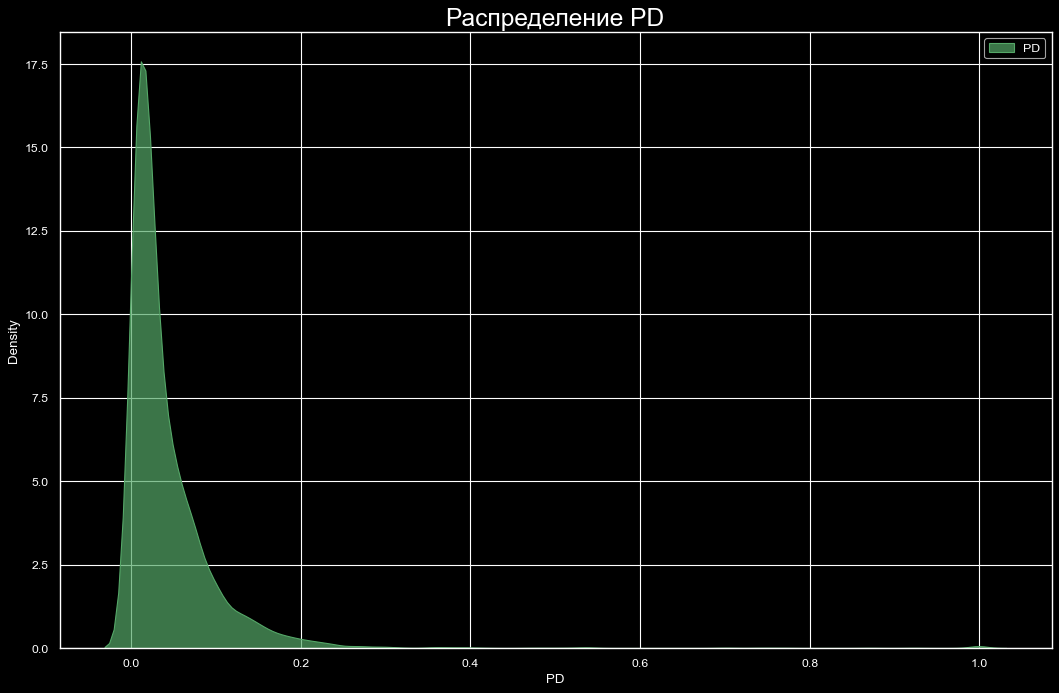

In [94]:
plt.figure(figsize=(16,10), dpi= 80)
sns.kdeplot(travel['PD'], shade=True, color="g", label="PD", alpha=.7, cmap="mako")
plt.style.use('dark_background')

# Decoration
plt.title('Распределение PD', fontsize=22)
plt.legend()
plt.show()

### Таргет

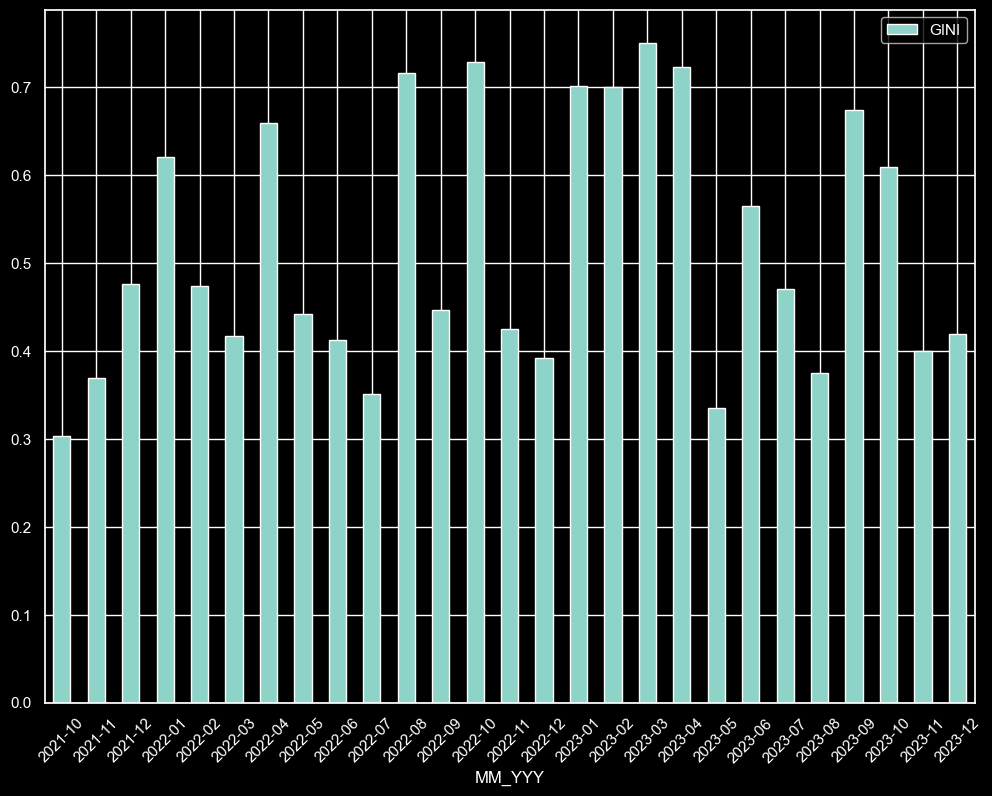

In [80]:
GINI.loc[(GINI.model=='travel')&(GINI.indicator=='60_6mob')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

### Ранний индикатор

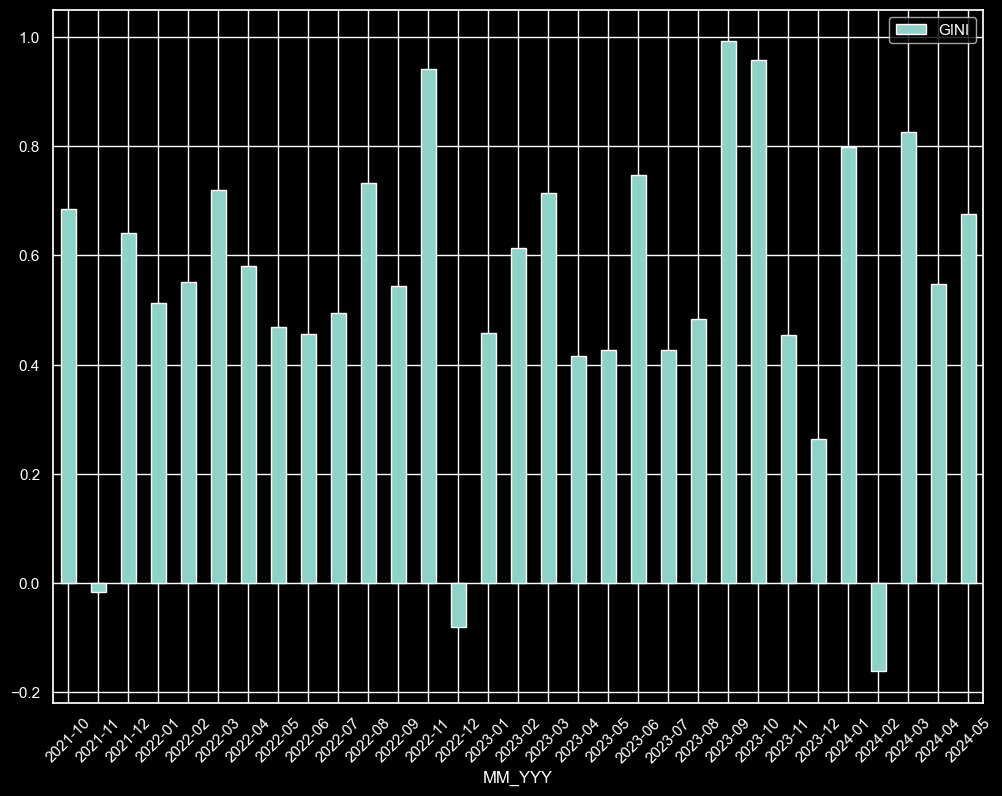

In [81]:
GINI.loc[(GINI.model=='travel')&(GINI.indicator=='FPD20')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

## 1.2 Факт\прогноз

### Таргет

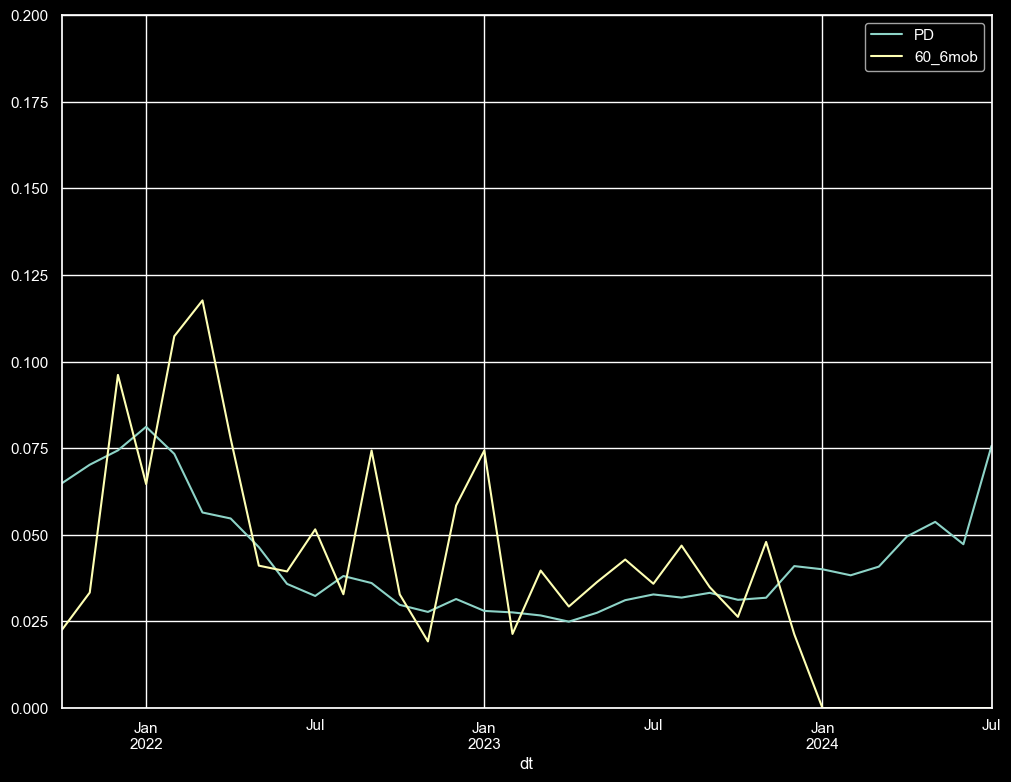

In [83]:
draw_fact_predict(travel, '60_6mob')

### Ранний индикатор

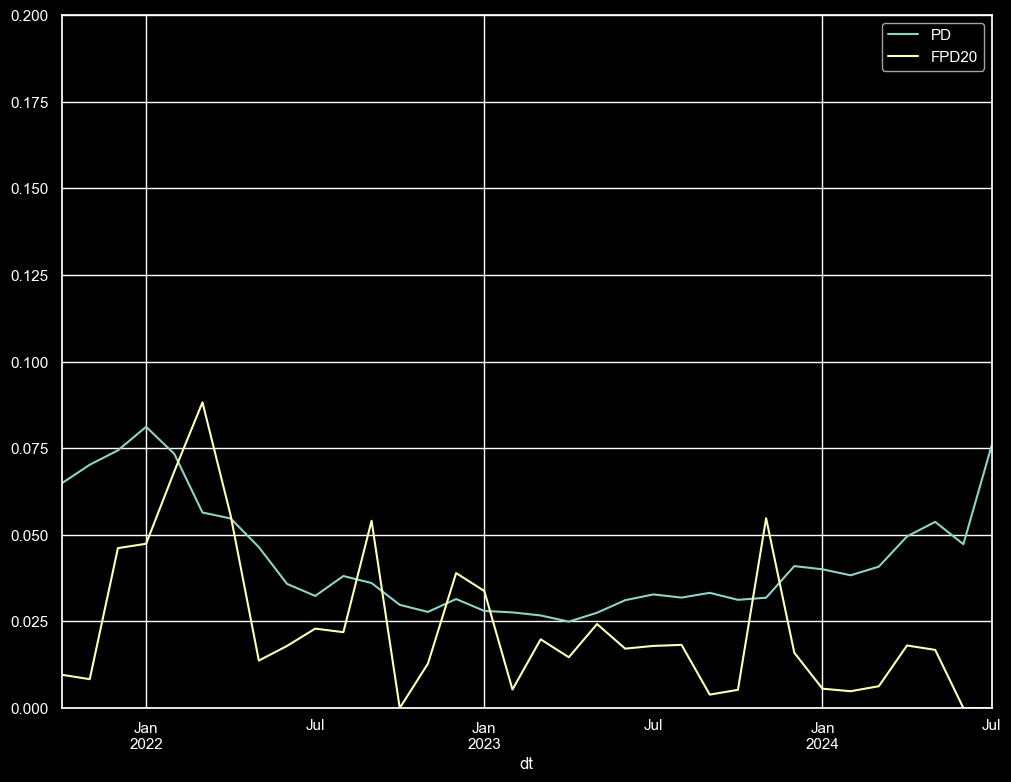

In [84]:
draw_fact_predict(travel, 'FPD20')

## 1.3 roc_auc

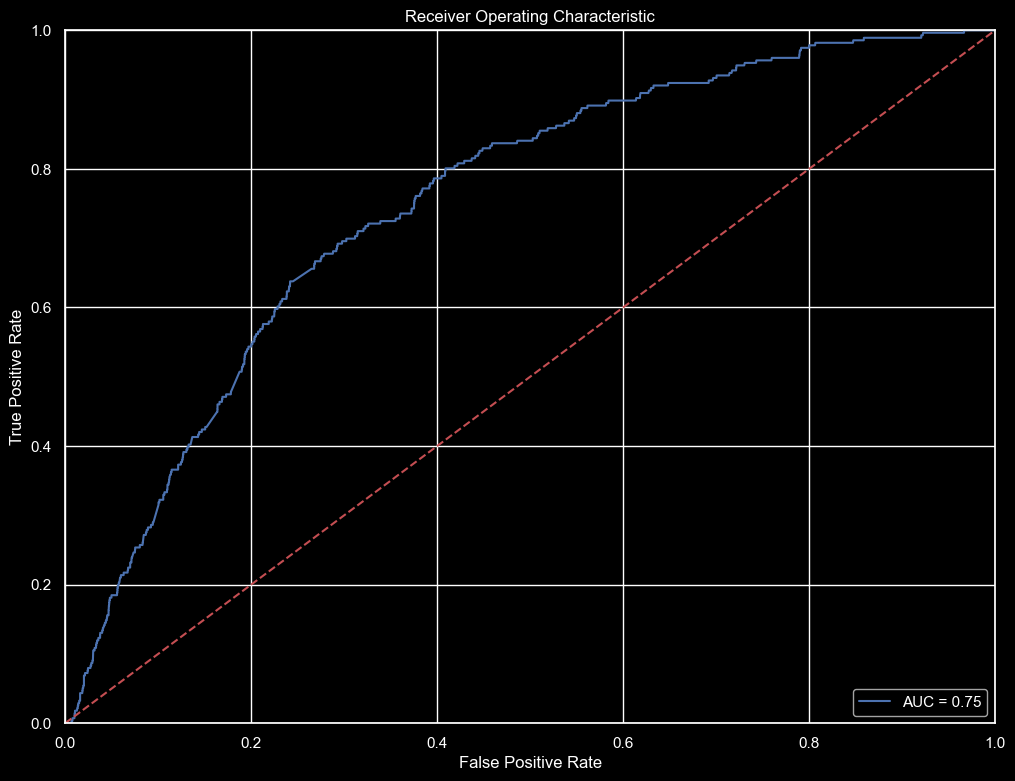

In [85]:
draw_roc_auc(travel, '60_6mob')

## Биномиальный тест

In [32]:
from statsmodels.stats.proportion import proportion_confint

#calculate 95% confidence interval with 56 successes in 100 trials
proportion_confint ( count=len(travel.loc[travel['60_6mob']==0]) , nobs=len(travel) , alpha = 0.05 , method = 'normal' )



(0.9628136812414793, 0.970543797932733)

<Axes: xlabel='dt', ylabel='PD'>

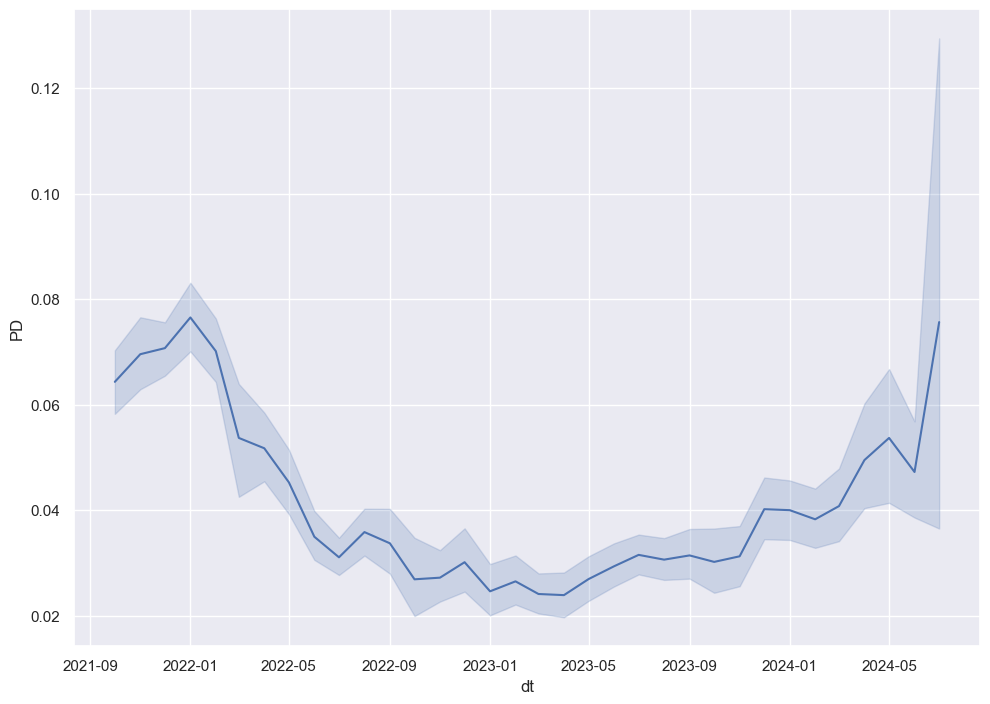

In [96]:
import seaborn as sns
plt.style.use('dark_background')
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.lineplot(x=travel['dt'], y=travel.loc[travel['60_6mob']==0]['PD'],ci= 95)
#final.loc['travel'].iat[3]=travel.loc[travel.dt.isin([dt, dt1, pd.to_datetime(dt)- relativedelta(months=1)])].shape[0]


## 1.4 PSI

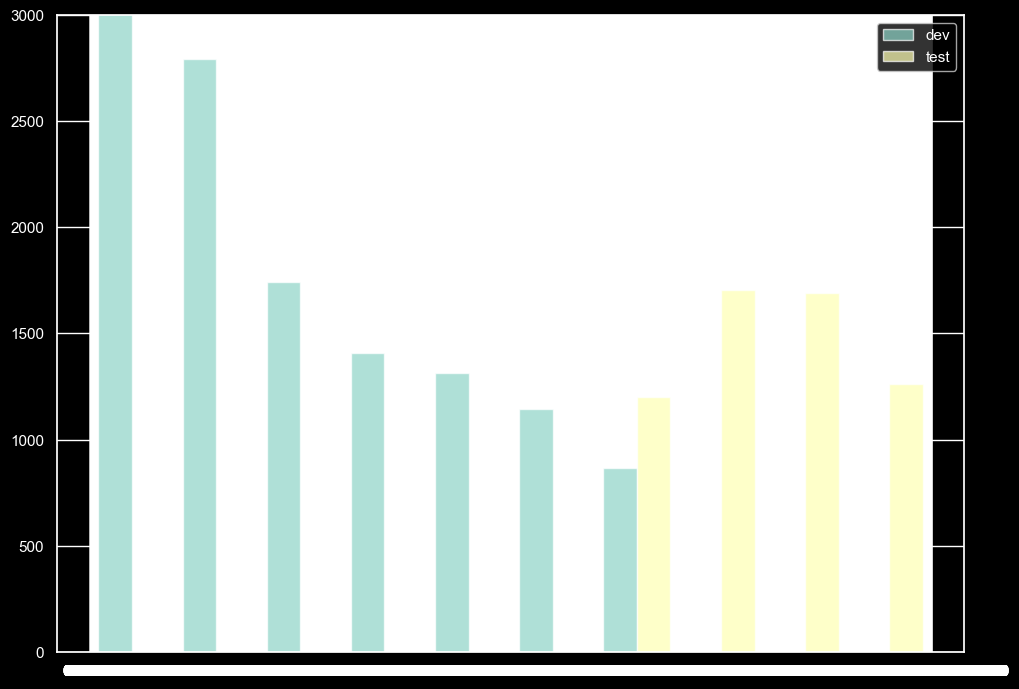

In [39]:
plt.style.use('dark_background')
PSI_travel_dev=PSI_travel_dev.rename(columns={'ParamValue':'PD'}).astype(str)
PSI_travel_test=PSI_travel_test.rename(columns={'ParamValue':'PD'}).astype(str)

PSI_travel_dev=PSI_travel_dev.sort_values(by=['PD'])
plt.hist([PSI_travel_dev.PD, PSI_travel_test.PD], 10, alpha=0.7, label=['dev', 'test'])
plt.legend(loc='upper right')
plt.ylim(0,3000)
plt.show()

### Общий

In [43]:
us=PSI_travel_dev.columns[2:]#['PD_travel', 'Travel_Cities_number', 'Travel_total_consumer_share_gr', 'Travel_Fico_score', 'Travel_score_megafon_score', 'Travel_score_Const', 'Travel_score_Total_overdue_amount', 'Travel_LIFETIMEBINValueId', 'Travel_negative_total', 'Travel_total_microcredits_share', 'Travel_Recent_inquiries_gr', 'Travel_fico_flag', 'Travel_Max_overdue_bin', 'Travel_Total_mortgages']
res1=PSI_c(PSI_travel_dev, PSI_travel_test, us)
final.at['travel', 'Фичи не в зеленой зоне']=res1.loc[res1.test_res!='green'].index.tolist()
final.at['travel', 'Кол-во фичей не в зеленой зоне']=str((res1.loc[res1.test_res!='green']).count()[1])+' из '+str(res1.shape[0])
final.at['travel', 'Валидационный светофор по PSI за 2Q 24года']=np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])<0.1, test, np.where((0.2<=(res1.loc[res1.test_res!='green'].count()/res1.shape[0]))|(res1.loc['PD', 'test_res']=='red'), test2, test1))[0]#np.where(res1.loc[res1.test_res!='green'].count()/res1.shape[0]>0.1, test1, test)[0]
res1

,Значение теста PSI,test_res
PD,0.197506,yellow
Travel_Max_overdue_bin,0.00685,green
Travel_Recent_inquiries_gr,0.05166,green
Travel_Total_mortgages,0.00363,green
Travel_fico_flag,0.03034,green
Travel_negative_total,0.037353,green
Travel_score_Const,0.00000,green
Travel_score_Total_overdue_amount,0.004798,green
Travel_score_megafon_score,2.652747,red
Travel_total_consumer_share_gr,0.65434,red


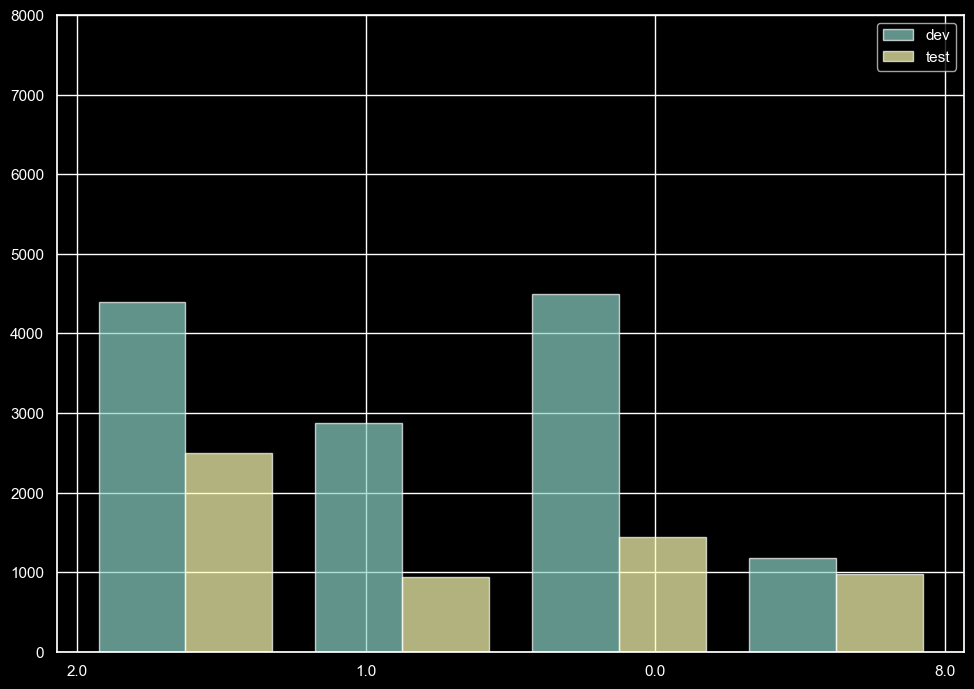

In [45]:
plt.style.use('dark_background')
plt.hist([PSI_travel_dev.Travel_Recent_inquiries_gr.astype(str), PSI_travel_test.Travel_Recent_inquiries_gr.astype(str)], 4, alpha=0.7, label=['dev', 'test'])
plt.legend(loc='upper right')
plt.ylim(0,8000)
plt.show()

### Помесячно

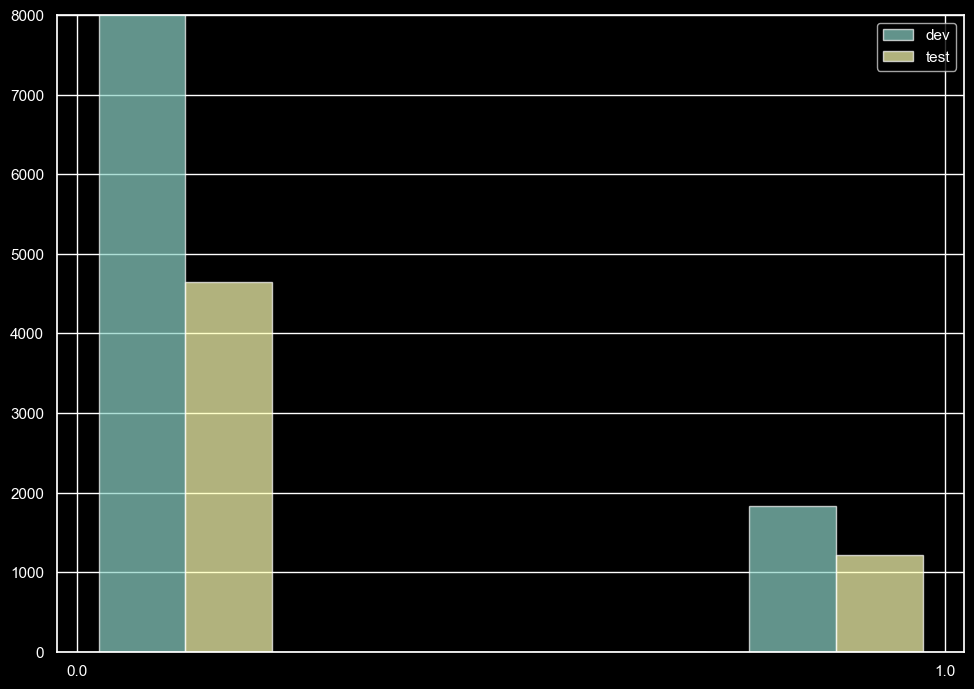

In [46]:
plt.style.use('dark_background')

plt.hist([PSI_travel_dev.Travel_fico_flag.astype(str), PSI_travel_test.Travel_fico_flag.astype(str)], 4, alpha=0.7, label=['dev', 'test'])
plt.legend(loc='upper right')
plt.ylim(0,8000)
plt.show()

## Тест Колмогорова-Смирнова 

In [47]:
s, p=ks_2samp(PSI_travel_dev['PD'], PSI_travel_test['PD'])
print('statistic', s, 'p_value', format(p, ".50f"))
ks_2samp(PSI_travel_dev['PD'], PSI_travel_test['PD'])

statistic 0.11676033847392786 p_value 0.00000000000000000000000000000000000000000000000239


KstestResult(statistic=0.11676033847392786, pvalue=2.3948889427632243e-48, statistic_location=0.03057, statistic_sign=-1)

# 2 Аэрофлот

## 2.1 GINI

### Таргет

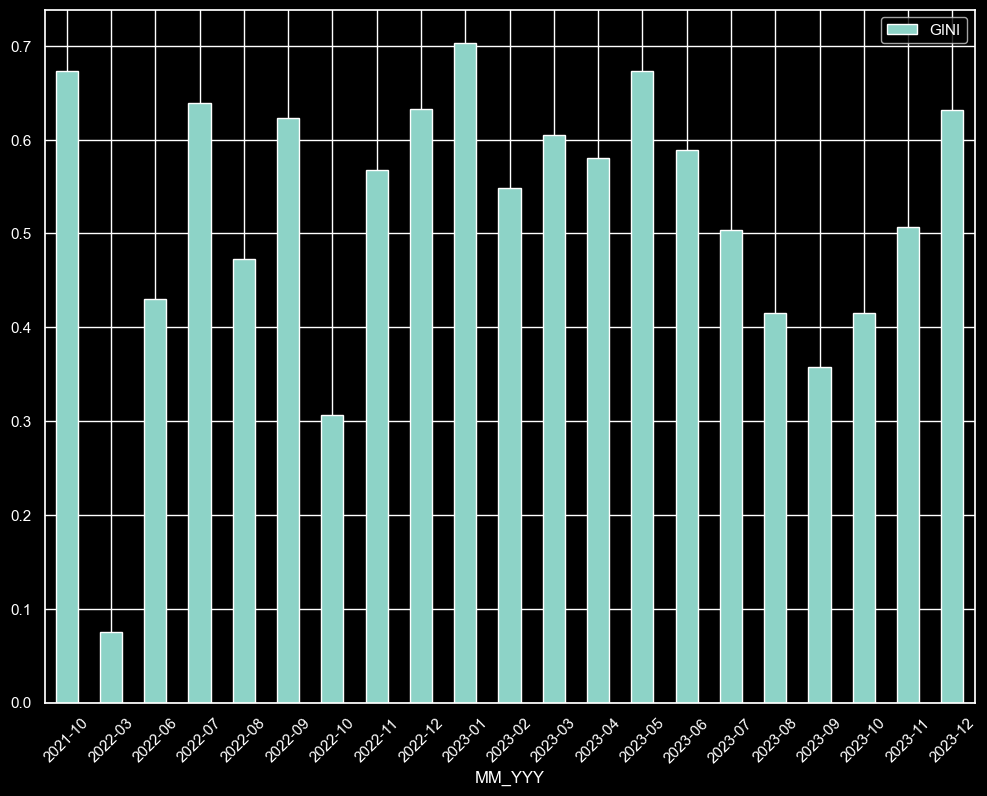

In [48]:
GINI.loc[(GINI.model=='afl')&(GINI.indicator=='60_6mob')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

### Ранний индикатор

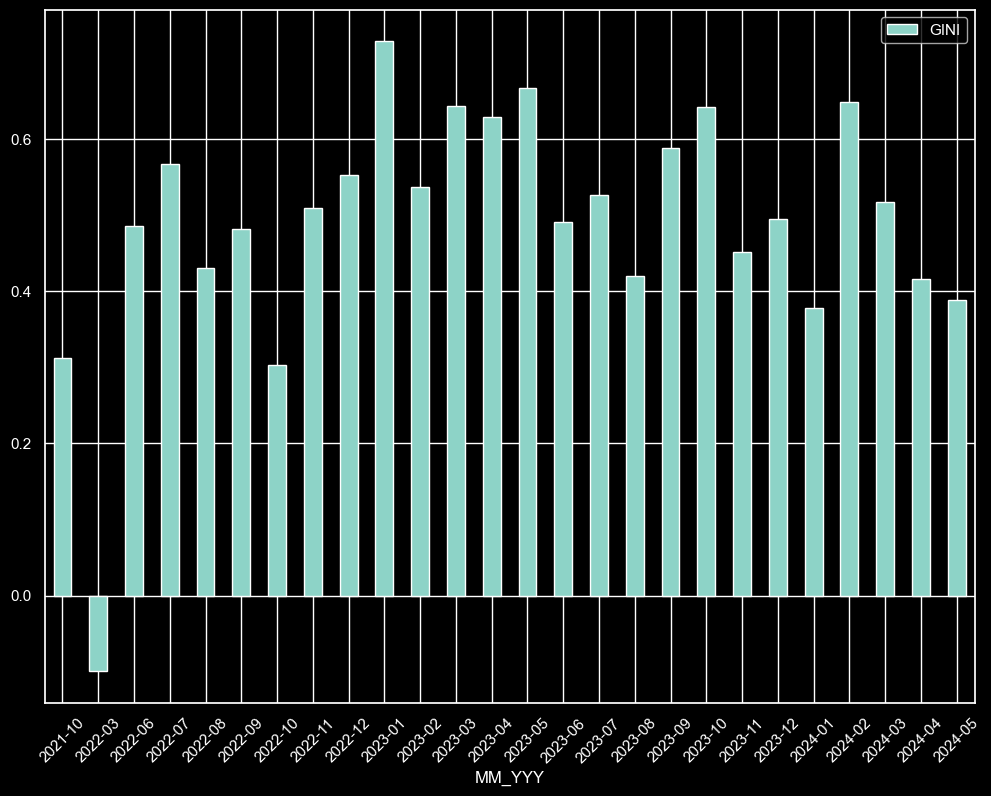

In [49]:
GINI.loc[(GINI.model=='afl')&(GINI.indicator=='FPD20')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

## 2.2 Факт\прогноз

### Таргет 

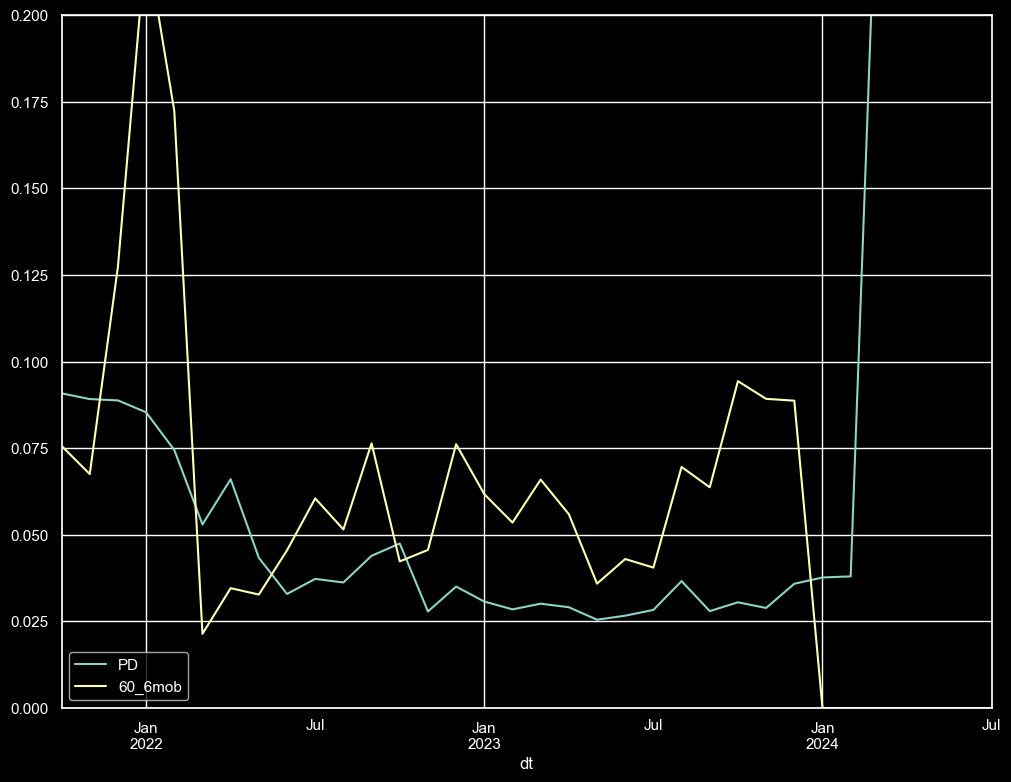

In [50]:
draw_fact_predict(afl, '60_6mob')

### Ранний индикатор

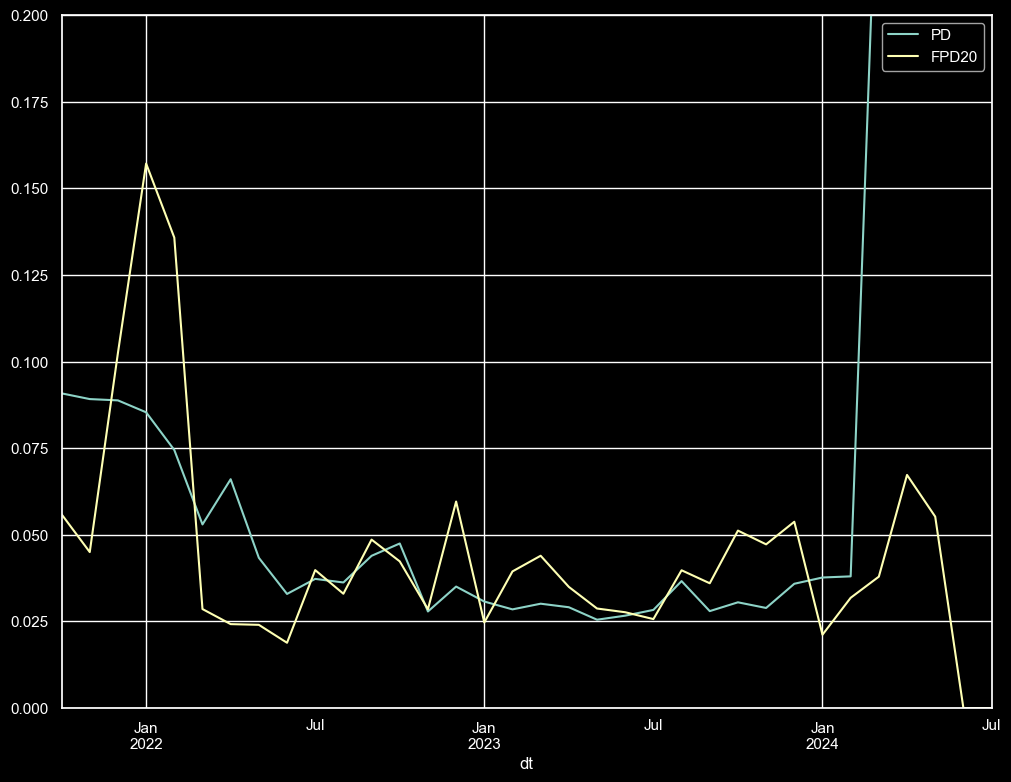

In [51]:
draw_fact_predict(afl, 'FPD20')

## 2.3 roc_auc

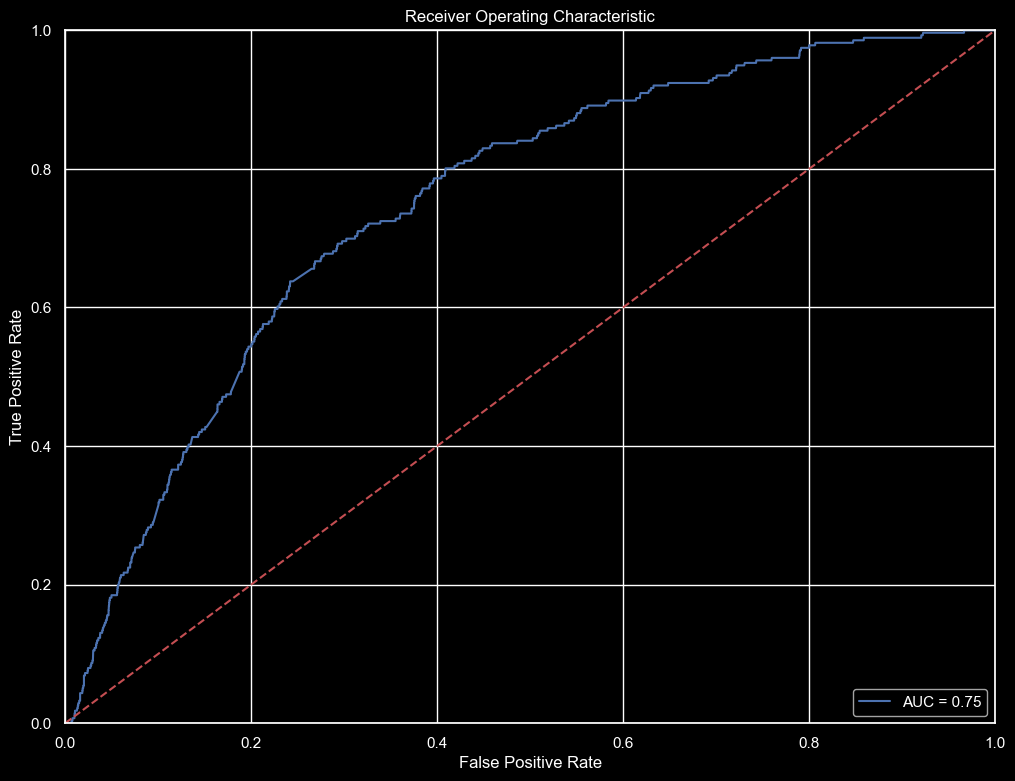

In [52]:
draw_roc_auc(travel, '60_6mob')

## 2.4 PSI

### Общий

In [53]:
us=PSI_afl_dev.columns[1:]#['PD_travel', 'Travel_Cities_number', 'Travel_total_consumer_share_gr', 'Travel_Fico_score', 'Travel_score_megafon_score', 'Travel_score_Const', 'Travel_score_Total_overdue_amount', 'Travel_LIFETIMEBINValueId', 'Travel_negative_total', 'Travel_total_microcredits_share', 'Travel_Recent_inquiries_gr', 'Travel_fico_flag', 'Travel_Max_overdue_bin', 'Travel_Total_mortgages']
res1=PSI_c(PSI_afl_dev, PSI_afl_test, us)
final.at['afl', 'Фичи не в зеленой зоне']=res1.loc[res1.test_res!='green'].index.tolist()[0:]
final.at['afl', 'Кол-во фичей не в зеленой зоне']=str((res1.loc[res1.test_res!='green']).count()[1])+' из '+str(res1.shape[0])
final.at['afl', 'Валидационный светофор по PSI за 2Q 24года']=np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])<0.1, test, np.where((0.2<=(res1.loc[res1.test_res!='green'].count()/res1.shape[0]))|(res1.loc['PD', 'test_res']=='red'), test2, test1))[0]#np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])>0.1, test1, test)[0]
#final.loc['afl'].iat[3]=afl.loc[afl.dt.isin([dt, dt1, pd.to_datetime(dt)- relativedelta(months=1)])].shape[0]

res1

,Значение теста PSI,test_res
AFL_Age_gr,0.00607,green
AFL_BLOCKCNTValueId,0.43261,red
AFL_Const,0.00000,green
AFL_Fico_score,1.567631,red
AFL_LIFETIMEBINValueId,3.46372,red
AFL_PAYMAXValueId,2.59370,red
PD,3.57702,red
AFL_Total_overdue_amount_bin,0.00449,green
AFL_ZipCodes_number,0.03457,green
AFL_dif_days,0.023682,green


## Распределение PD

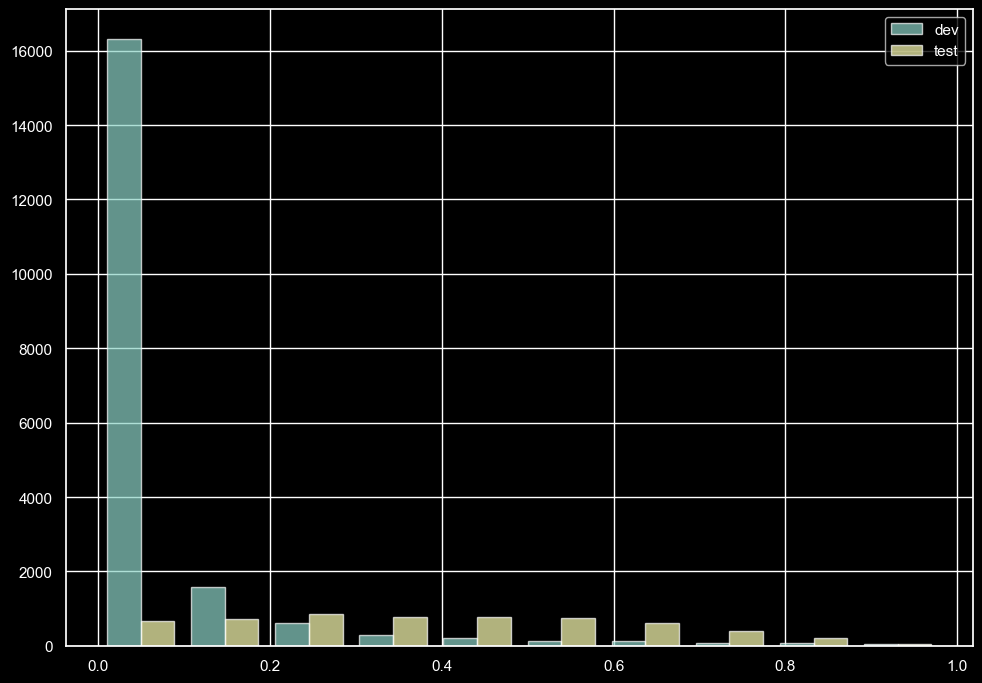

In [54]:
plt.style.use('dark_background')
plt.hist([PSI_afl_dev.PD, PSI_afl_test.PD], 10, alpha=0.7, label=['dev', 'test'])
plt.legend(loc='upper right')
#plt.ylim(0,8000)
plt.show()

### Тест Колмогорова-Смирнова

In [55]:
s, p=ks_2samp(PSI_afl_dev['PD'], PSI_afl_test['PD'])
print('statistic', s, 'p_value', format(p, ".50f"))
ks_2samp(PSI_afl_dev['PD'], PSI_afl_test['PD'])


statistic 0.7805795875077508 p_value 0.00000000000000000000000000000000000000000000000000


KstestResult(statistic=0.7805795875077508, pvalue=0.0, statistic_location=0.14471, statistic_sign=1)

# 3. Яндекс

## 3.1 GINI

### Таргет

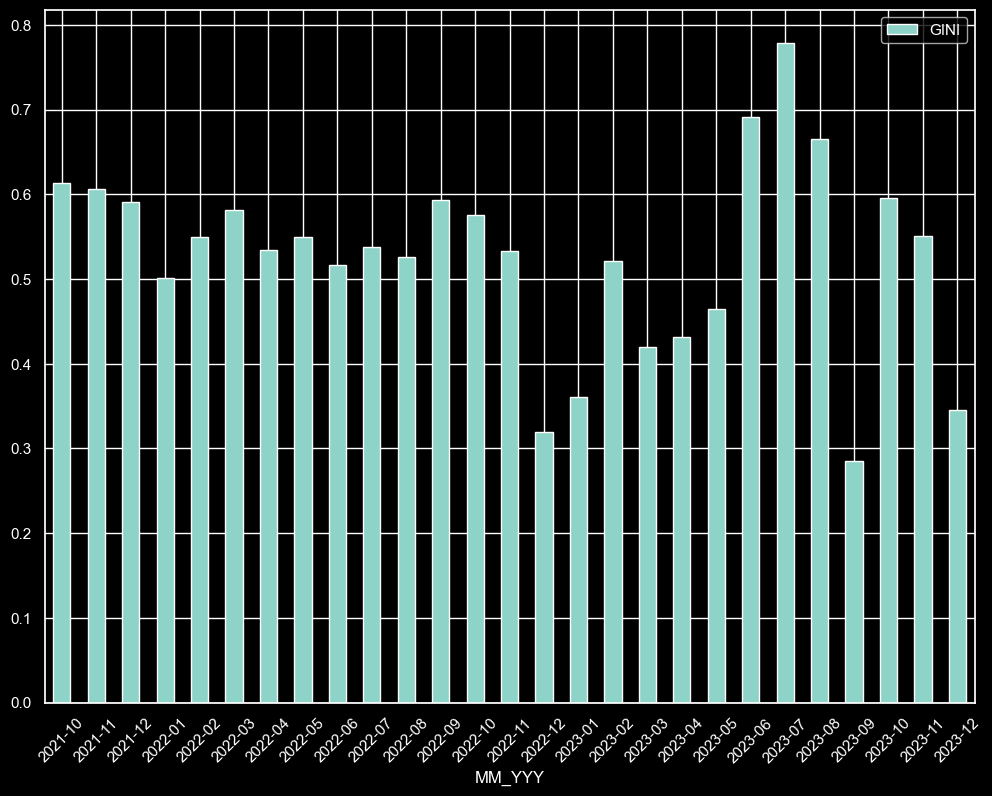

In [56]:
GINI.loc[(GINI.model=='yandex')&(GINI.indicator=='60_6mob')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

### Ранний индикатор

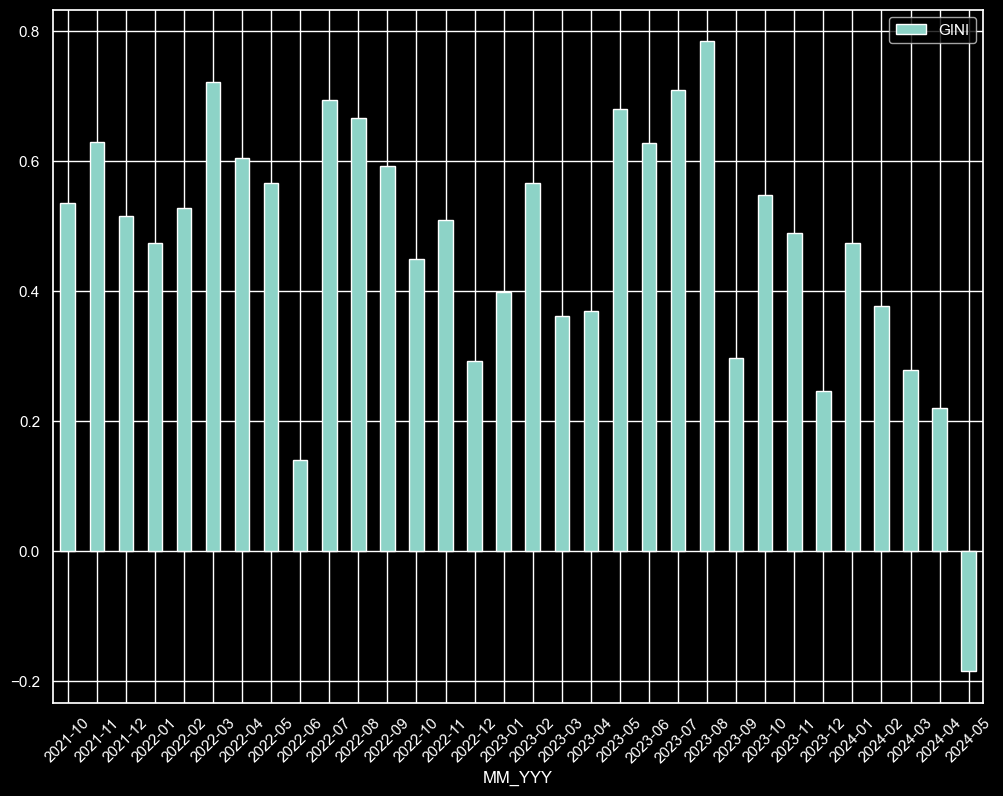

In [57]:
GINI.loc[(GINI.model=='yandex')&(GINI.indicator=='FPD20')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

## 3.2 Факт\прогноз

### Таргет

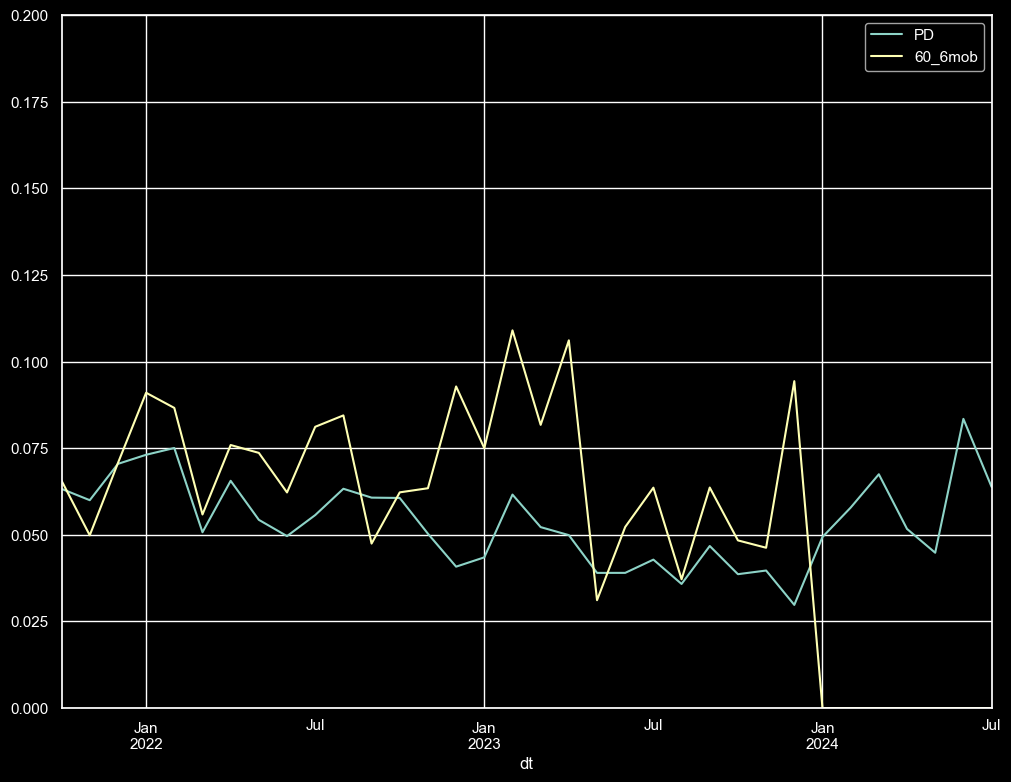

In [58]:
yandex.dt=pd.to_datetime(yandex.dt)
draw_fact_predict(yandex, '60_6mob')

### Ранний индикатор

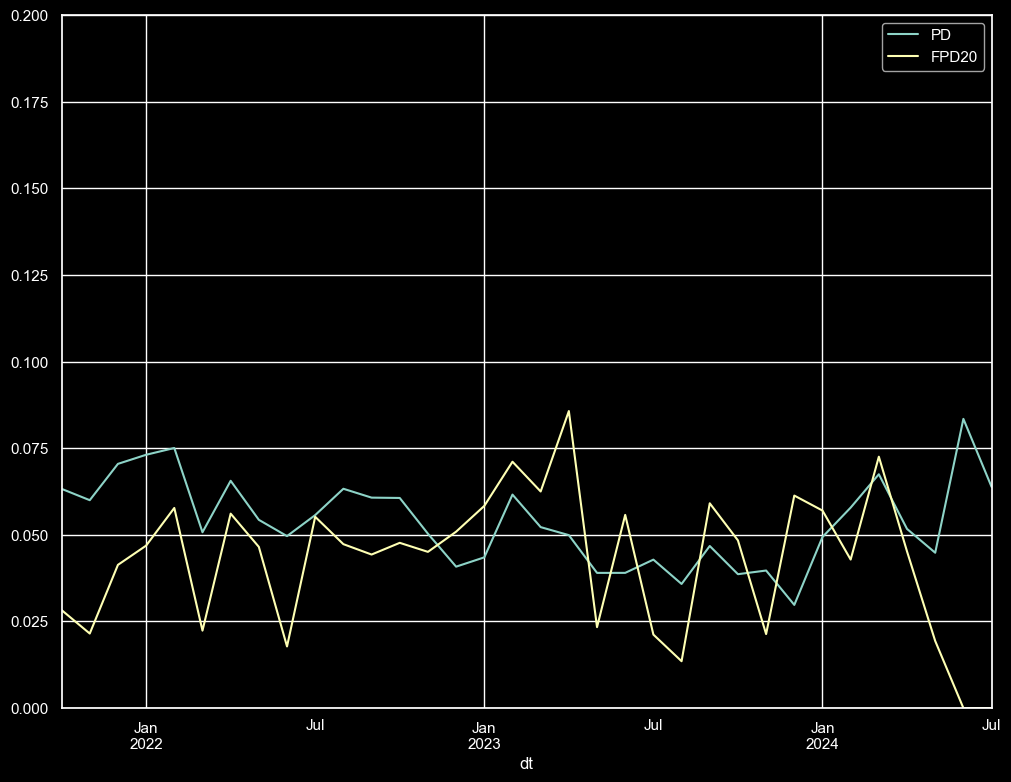

In [59]:
draw_fact_predict(yandex, 'FPD20') 

## 3.3 roc_auc

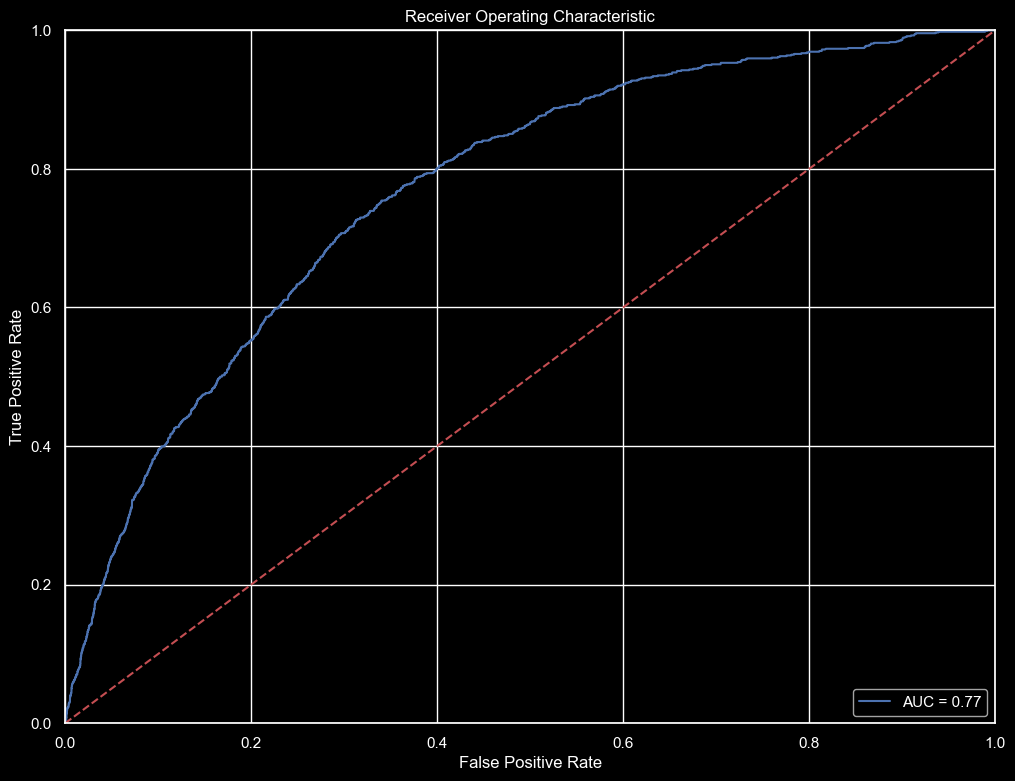

In [60]:
draw_roc_auc(yandex, '60_6mob')

## 3.4 PSI

In [61]:
us=PSI_ya_dev.columns[1:]#['PD_travel', 'Travel_Cities_number', 'Travel_total_consumer_share_gr', 'Travel_Fico_score', 'Travel_score_megafon_score', 'Travel_score_Const', 'Travel_score_Total_overdue_amount', 'Travel_LIFETIMEBINValueId', 'Travel_negative_total', 'Travel_total_microcredits_share', 'Travel_Recent_inquiries_gr', 'Travel_fico_flag', 'Travel_Max_overdue_bin', 'Travel_Total_mortgages']
res1=PSI_c(PSI_ya_dev, PSI_ya_test, us)
final.at['yandex', 'Фичи не в зеленой зоне']=res1.loc[res1.test_res!='green'].index.tolist()[0:]
final.at['yandex', 'Кол-во фичей не в зеленой зоне']=str((res1.loc[res1.test_res!='green']).count()[1])+' из '+str(res1.shape[0])
final.at['yandex', 'Валидационный светофор по PSI за 2Q 24года']=np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])<0.1, test, np.where((0.2<=(res1.loc[res1.test_res!='green'].count()/res1.shape[0]))|(res1.loc['PD', 'test_res']=='red'), test2, test1))[0]#np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])>0.1, test1, test)[0]
#final.loc['yandex'].iat[3]=yandex.loc[yandex.dt.isin([dt, dt1, pd.to_datetime(dt)- relativedelta(months=1)])].shape[0]

res1

,Значение теста PSI,test_res
Ex_Megafon_IntegralScore,0.03117,green
Ex_Megafon_LifeTimeBin,0.12068,yellow
Ex_NBKI_MaxOverdue,0.351913,red
Ex_NBKI_NbActiveMicrocredits,0.044135,green
Ex_NBKI_RecentInquiries,0.028214,green
Ex_NBKI_ScoreRetailPersonal,0.024573,green
Ex_NBKI_TotalAccounts,0.02376,green
Ex_NBKI_TotalActiveAccounts,0.080256,green
Ex_NBKI_TotalConsumerCredit,0.347529,red
Ex_NBKI_TotalNegativeAccounts,0.038189,green


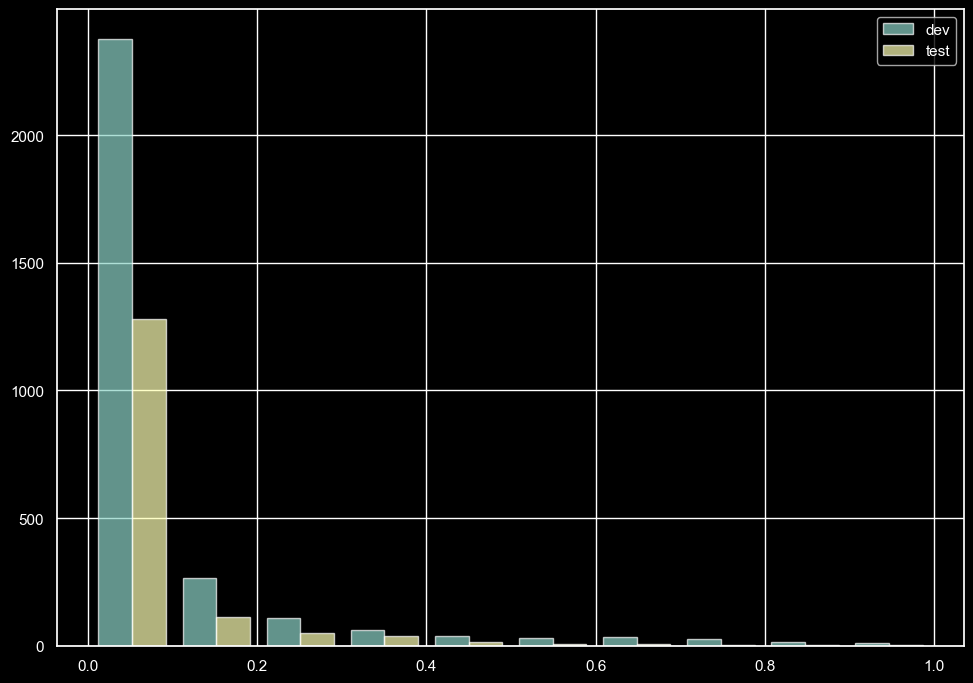

In [62]:
plt.style.use('dark_background')
plt.hist([PSI_ya_dev.PD, PSI_ya_test.PD], 10, alpha=0.7, label=['dev', 'test'])
plt.legend(loc='upper right')
#plt.ylim(0,8000)
plt.show()

### Тест Колмогорова-Смирнова

In [63]:
ks_2samp(PSI_ya_dev['PD'], PSI_ya_test['PD'])

KstestResult(statistic=0.057946801455711, pvalue=0.0022613267754287595, statistic_location=0.07124, statistic_sign=-1)

# 4. ALL

## 4.1 Gini

### Таргет

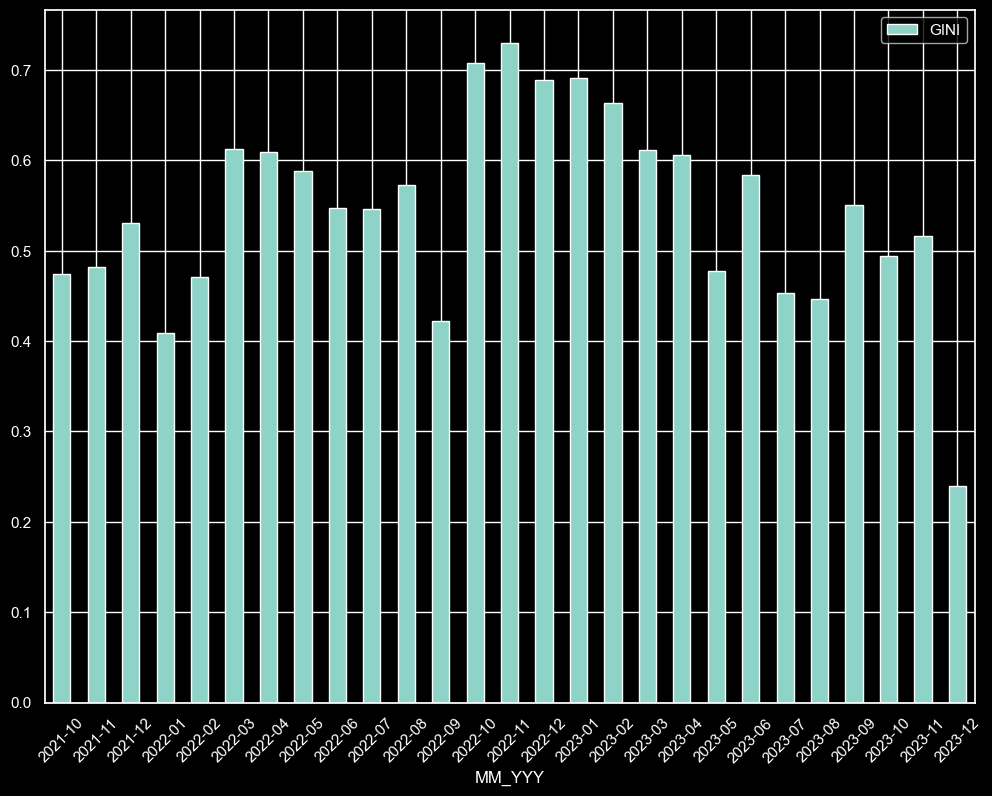

In [64]:
GINI.loc[(GINI.model=='all1')&(GINI.indicator=='90_6mob')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

### Ранний индикатор

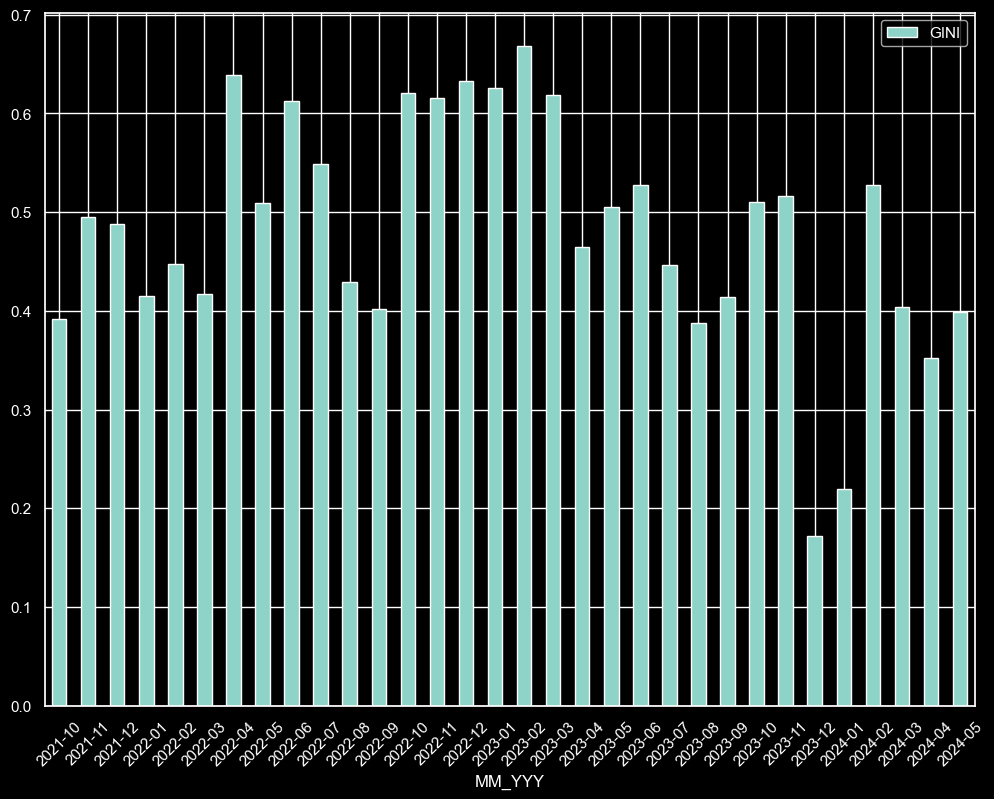

In [65]:
GINI.loc[(GINI.model=='all1')&(GINI.indicator=='FPD20')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

## 4.2 Факт\прогноз

### Таргет

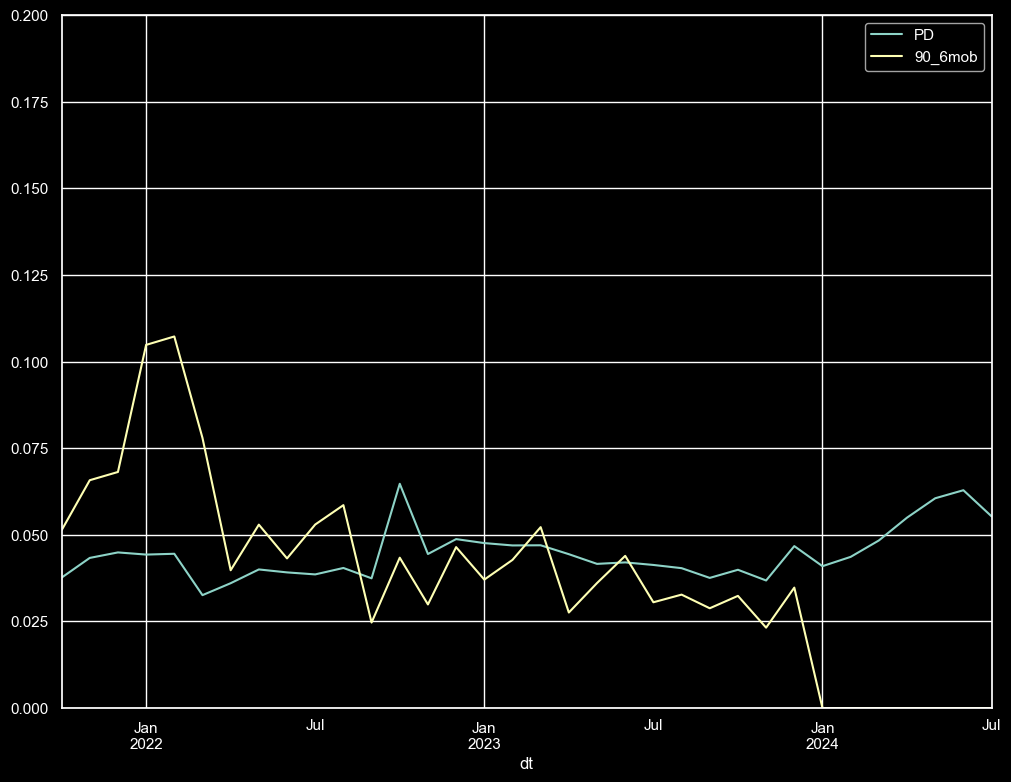

In [66]:
draw_fact_predict(all1, '90_6mob')

### Ранний индикатор

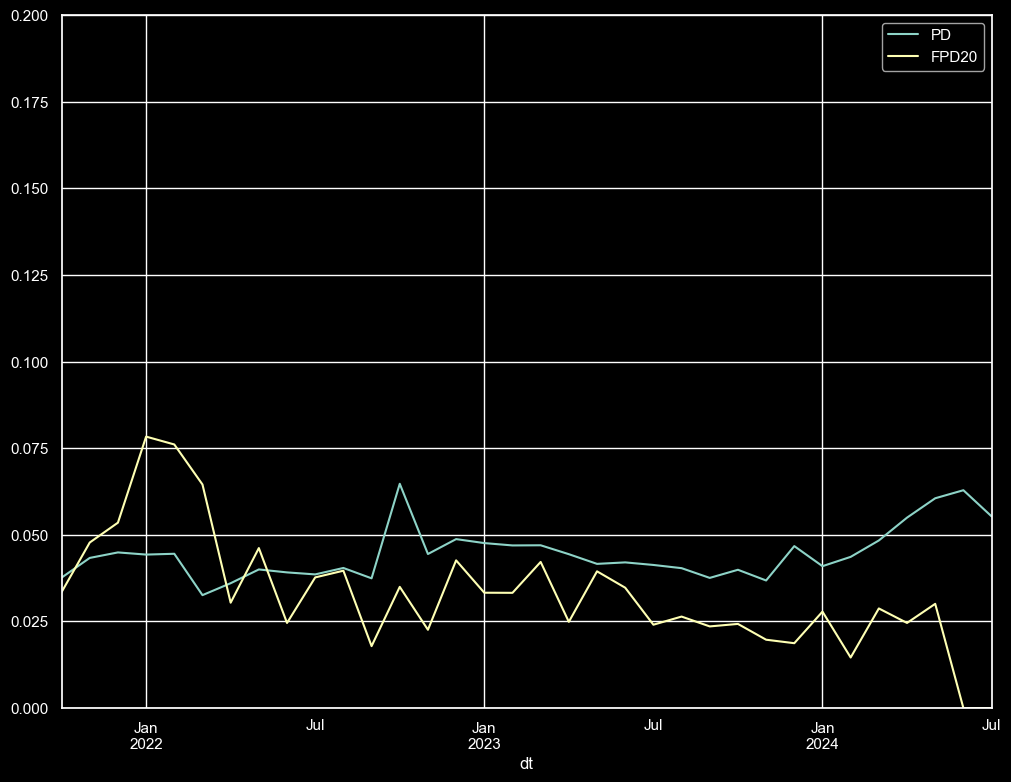

In [67]:
draw_fact_predict(all1, 'FPD20')

## 4.3 roc_auc

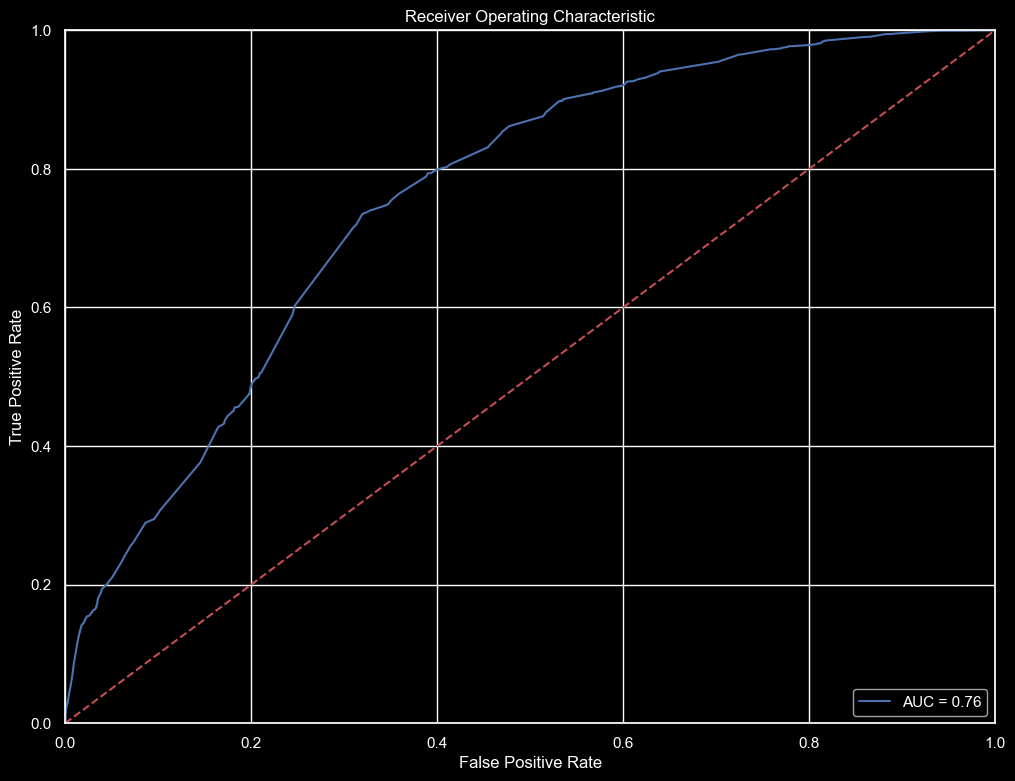

In [68]:
draw_roc_auc(all1, '90_6mob')

## 4.4 PSI

In [69]:
us=PSI_all_dev.columns[1:]#['PD_travel', 'Travel_Cities_number', 'Travel_total_consumer_share_gr', 'Travel_Fico_score', 'Travel_score_megafon_score', 'Travel_score_Const', 'Travel_score_Total_overdue_amount', 'Travel_LIFETIMEBINValueId', 'Travel_negative_total', 'Travel_total_microcredits_share', 'Travel_Recent_inquiries_gr', 'Travel_fico_flag', 'Travel_Max_overdue_bin', 'Travel_Total_mortgages']
res1=PSI_c(PSI_all_dev, PSI_all_test, us)
final.at['all1', 'Фичи не в зеленой зоне']=res1.loc[res1.test_res!='green'].index.tolist()[0:]
final.at['all1', 'Кол-во фичей не в зеленой зоне']=str((res1.loc[res1.test_res!='green']).count()[1])+' из '+str(res1.shape[0])
final.at['all1', 'Валидационный светофор по PSI за 2Q 24года']=np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])<0.1, test, np.where((0.2<=(res1.loc[res1.test_res!='green'].count()/res1.shape[0]))|(res1.loc['PD', 'test_res']=='red'), test2, test1))[0]#np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])>0.1, test1, test)[0]
#final.loc['all1'].iat[3]=all1.loc[all1.dt.isin([dt, dt1, pd.to_datetime(dt)- relativedelta(months=1)])].shape[0]

res1

,Значение теста PSI,test_res
Age,0.014753,green
Ex_Megafon_IntegralScore,0.104417,yellow
Ex_NBKI_RecentInquiries,0.150697,yellow
Ex_NBKI_ScoreRetailPersonal,0.079414,green
PD,0.04561,green
SM_Age,0.00017,green
SM_FicoScore,0.01335,green
SM_MegafonScore,0.00434,green
SM_RecentInquiries,0.01814,green


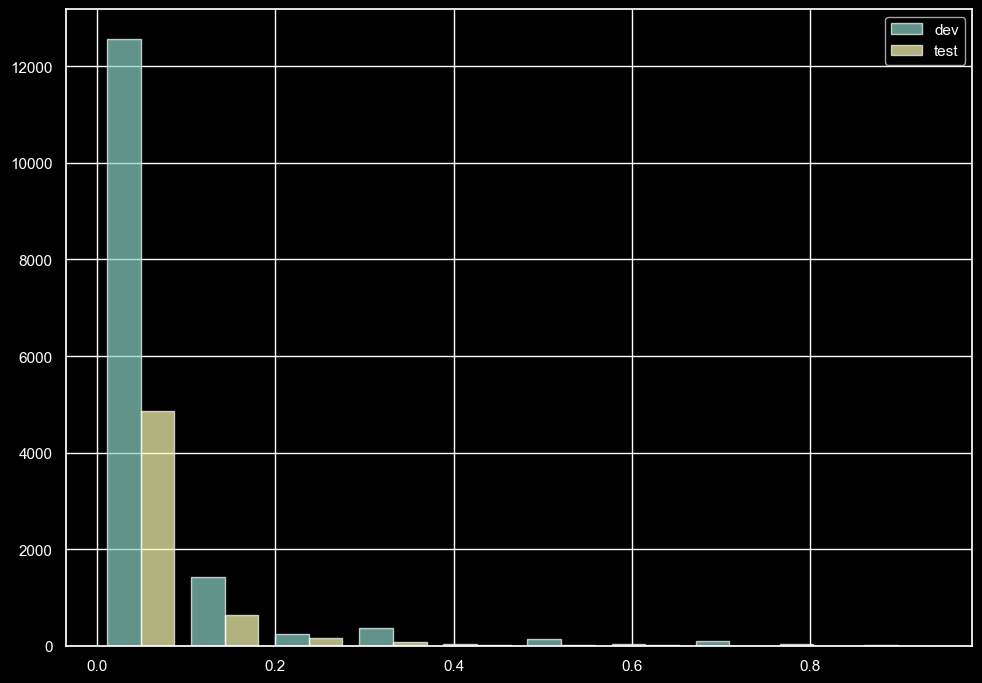

In [70]:
plt.style.use('dark_background')
plt.hist([PSI_all_dev.PD, PSI_all_test.PD], 10, alpha=0.7, label=['dev', 'test'])
plt.legend(loc='upper right')
#plt.ylim(0,8000)
plt.show()

## Помесячно

### Тест Колмогорова-Смирнова

In [71]:
s, p=ks_2samp(PSI_all_dev['PD'], PSI_all_test['PD'])
print('statistic', s, 'p_value', format(p, ".50f"))
#Если асимптотическая значимость(pvalue)>0.05, то распределение нормальное

statistic 0.06749020200283734 p_value 0.00000000000000006073301141687332152348175364167159


# 5. repeated

## 5.1 Gini

### Таргет

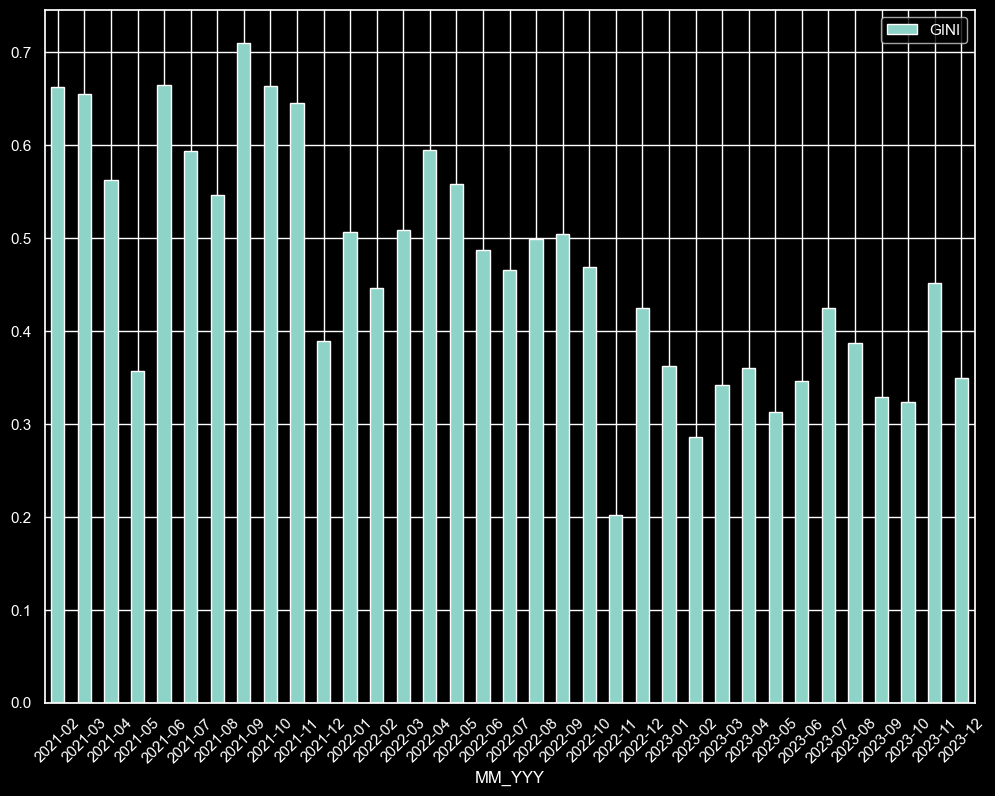

In [72]:
GINI.loc[(GINI.model=='repeated')&(GINI.indicator=='90_6mob')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

### Ранний индикатор

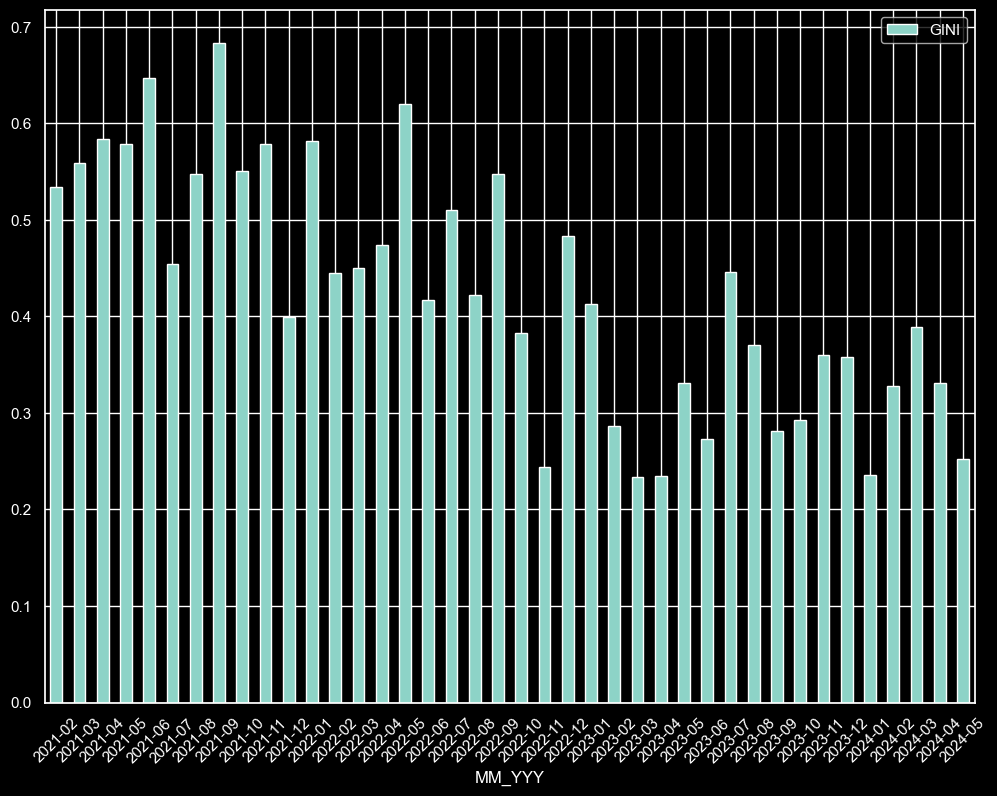

In [73]:
GINI.loc[(GINI.model=='repeated')&(GINI.indicator=='FPD20')].drop_duplicates().sort_values(by=['MM_YYY']).plot.bar(x='MM_YYY', y='GINI', figsize=(12,9), rot=45)
plt.show()

## 5.2 Факт\прогноз

### Таргет

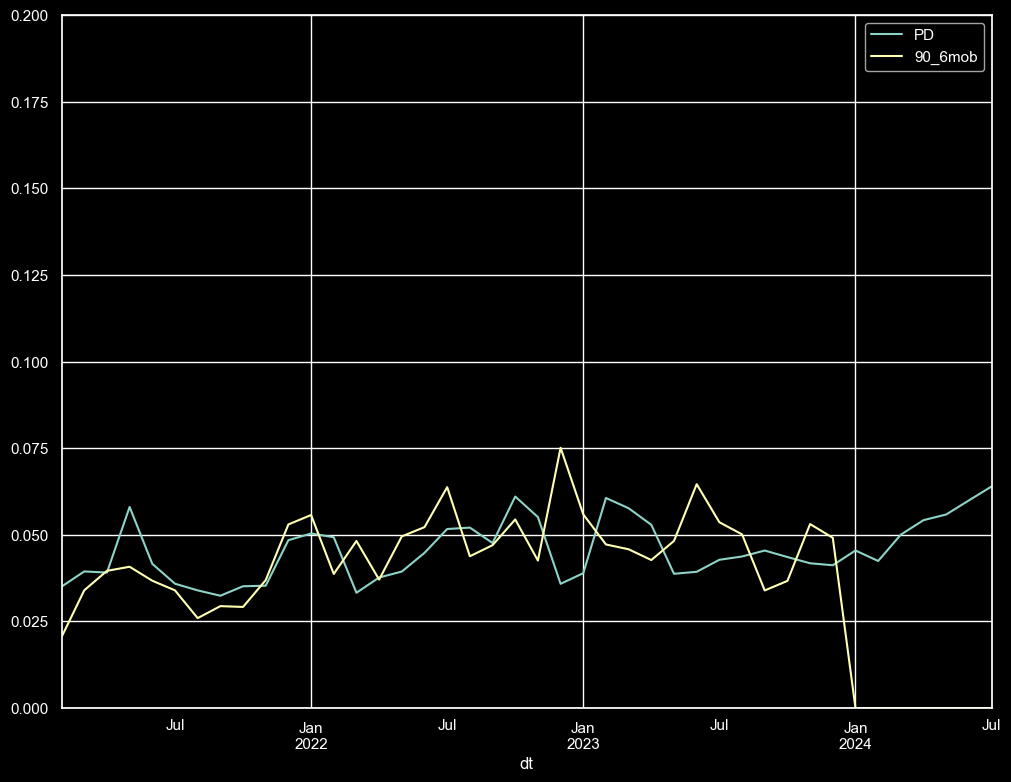

In [74]:
draw_fact_predict(repeated, '90_6mob')

### Ранний индикатор

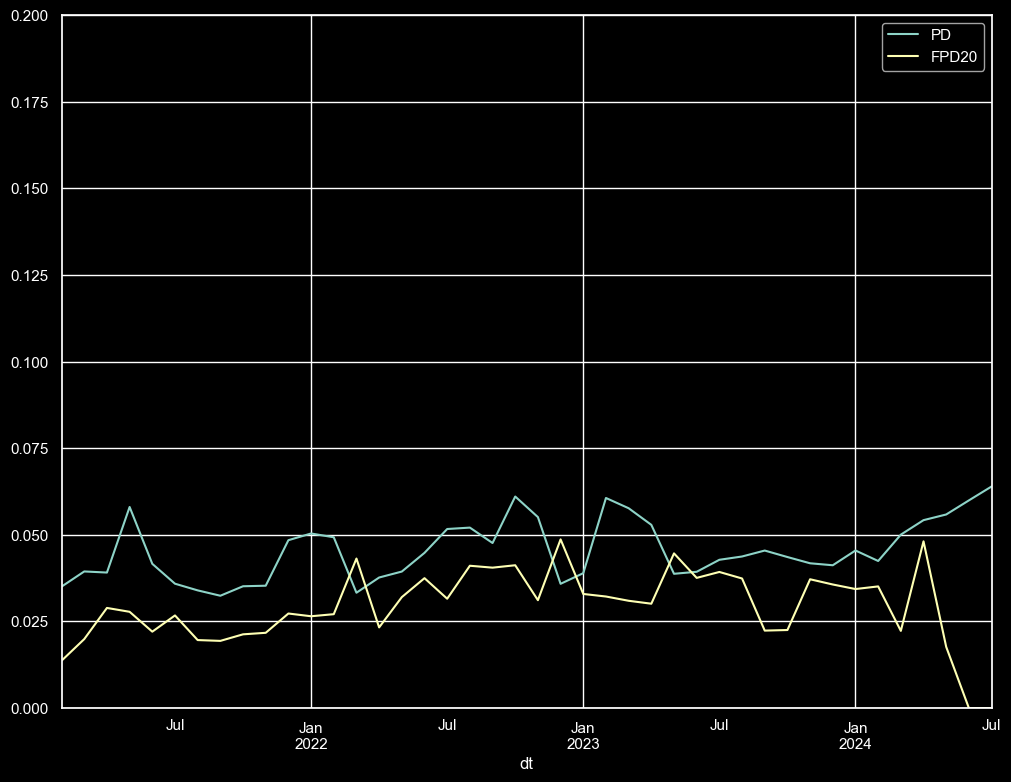

In [75]:
draw_fact_predict(repeated, 'FPD20')

# 5.3 roc_auc

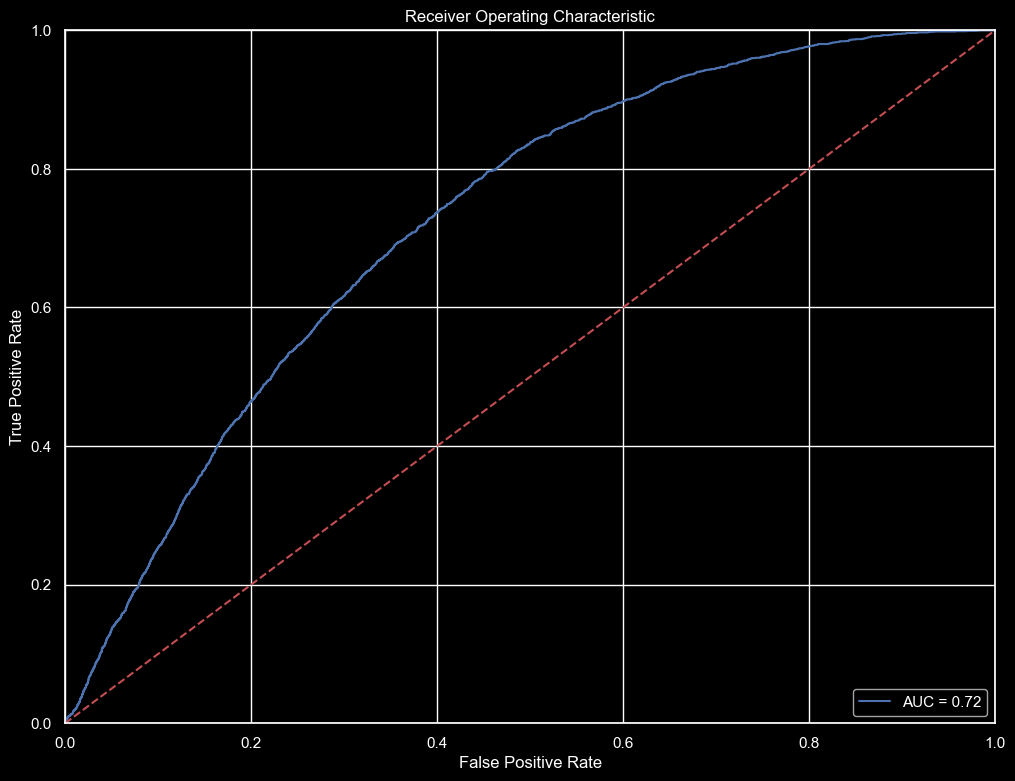

In [76]:
draw_roc_auc(repeated, '90_6mob')

## PSI

In [109]:
query1 = """ 
select distinct app.id, app.dtinput, PD, bki.Fico_score fico,bki.Is_FICO fico_flag, recent_inquiries, Nb_active_mortgages, Total_microcredits, Total_active_accounts, Total_overdue_amount, org.IdChannel, PDN, 
case when isnull(app.linsurAmount,0)=0 and  isnull(app.PInsurAmount,0)=0 then 0
        when isnull(app.linsurAmount,0)>0 and  isnull(app.PInsurAmount,0)=0 then 1
        when isnull(app.linsurAmount,0)=0 and  isnull(app.PInsurAmount,0)>0 then 1
        when isnull(app.linsurAmount,0)>0 and  isnull(app.PInsurAmount,0)>0 then 2                
        else '' end insurance 
from DMS..Output_vector as ov
inner join RISK_REPORT..riskmetrics as r on ov.AppId=r.AppId 
inner join Billing..Orders o on o.AppId=ov.AppId
inner join Billing..Applications app on app.id=o.AppId
inner join Billing..Organization org on app.OrganizationId=org.id
inner join Billing..Client cl on cl.id = r.Clientid
inner join [DMS].[dbo].Input_vector_data inp on (ov.AppId=app.id)
inner join [DMS].[dbo].Input_vector_bki bki on (bki.AppId=app.id)


where ov.Timestamp>='2020-06-01'
		and ov.PD is not null	
		and r.client_type='old'
		and cl.NonResident=0
		and cl.IsTest=0
		and r.sitename not like '%тест%'
		and r.Channel not like '%Тест%'
		and r.Channel not in ('Яндекс RCC', 'Эльдорадо', 'КЭШ Яндекс', 'Продавай', 'CarPrice')
		and  o.Cancellation!=1
"""

conn = pyodbc.connect('DRIVER={SQL Server};SERVER=192.168.20.16;DATABASE=billing;UID=sa;PWD=rjkjrhtlbn')
cursor = conn.cursor()
PSI_repeated = pd.read_sql_query(query1, conn)
conn.commit()
conn.close()


In [110]:
us=['PD', 'fico', 'fico_flag', 'recent_inquiries',
       'Nb_active_mortgages', 'Total_microcredits', 'Total_active_accounts',
       'Total_overdue_amount', 'IdChannel', 'PDN', 'insurance']
PSI_repeated.dtinput=PSI_repeated.dtinput.dt.strftime('%Y-%m')
PSI_repeated=PSI_repeated.rename(columns={'PD_real':'PD'})

PSI_repeated_dev=PSI_repeated.loc[(PSI_repeated.dtinput<(pd.to_datetime('2023-02-01').strftime('%Y-%m')))]
PSI_repeated_test=PSI_repeated.loc[(PSI_repeated.dtinput<=(pd.to_datetime('2024-01-31').strftime('%Y-%m')))&(PSI_repeated.dtinput>=(pd.to_datetime('2023-11-01').strftime('%Y-%m')))]


In [113]:
#us=PSI_repeated_dev.columns[4:]#['PD_travel', 'Travel_Cities_number', 'Travel_total_consumer_share_gr', 'Travel_Fico_score', 'Travel_score_megafon_score', 'Travel_score_Const', 'Travel_score_Total_overdue_amount', 'Travel_LIFETIMEBINValueId', 'Travel_negative_total', 'Travel_total_microcredits_share', 'Travel_Recent_inquiries_gr', 'Travel_fico_flag', 'Travel_Max_overdue_bin', 'Travel_Total_mortgages']
res1=PSI_c(PSI_repeated_dev, PSI_repeated_test, us)
final.at['repeated', 'Кол-во фичей не в зеленой зоне']=str((res1.loc[res1.test_res!='green']).count()[1])+' из '+str(res1.shape[0])
final.at['repeated', 'Фичи не в зеленой зоне']=res1.loc[res1.test_res!='green'].index.tolist()[0:]
final.at['repeated', 'Валидационный светофор по PSI за 2Q 24года']=np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])<0.1, test, np.where((0.2<=(res1.loc[res1.test_res!='green'].count()/res1.shape[0]))|(res1.loc['PD', 'test_res']=='red'), test2, test1))[0]#np.where(((res1.loc[res1.test_res!='green'].count()/res1.shape[0])>0.1)|, test1, test)[0]
final.at['all1', 'Размерность тест выборки PSI']=PSI_all_test.shape[0]#loc[PSI_all_test['dt'].isin([PSI_all_test.dt.max(), (pd.to_datetime(PSI_all_test.dt.max())- relativedelta(months=1)).strftime('%Y-%m'), (pd.to_datetime(PSI_all_test.dt.max())- relativedelta(months=2)).strftime('%Y-%m')])].shape[0]
final.at['yandex', 'Размерность тест выборки PSI']=PSI_ya_test.shape[0]#.loc[PSI_ya_test['dt'].isin([PSI_ya_test.dt.max(), (pd.to_datetime(PSI_ya_test.dt.max())- relativedelta(months=1)).strftime('%Y-%m'),(pd.to_datetime(PSI_ya_test.dt.max())- relativedelta(months=2)).strftime('%Y-%m')])].shape[0]
final.at['repeated', 'Размерность тест выборки PSI']=PSI_repeated_test.shape[0]#.loc[PSI_repeated_test.dtapp.isin([PSI_repeated_test.dtapp.max(), (pd.to_datetime(PSI_repeated_test.dtapp.max())- relativedelta(months=1)).strftime('%Y-%m'), (pd.to_datetime(PSI_repeated_test.dtapp.max())- relativedelta(months=2)).strftime('%Y-%m')])].shape[0]
final.at['afl', 'Размерность тест выборки PSI']=PSI_afl_test.shape[0]#.loc[PSI_afl_test.dt.isin([PSI_afl_test.max(), (pd.to_datetime(dt)- relativedelta(months=1)).strftime('%Y-%m'), dt1])].shape[0]
final.at['travel', 'Размерность тест выборки PSI']=PSI_travel_test.shape[0]#.loc[PSI_travel_test['Дата выдачи'].isin([dt, (pd.to_datetime(dt)- relativedelta(months=1)).strftime('%Y-%m'), dt1])].shape[0]
final.at['afl_2024', 'Размерность тест выборки PSI']='-'

res1

# np.where((res1.loc[res1.test_res!='green'].count()/res1.shape[0])<0.1, test, np.where((0.2<=(res1.loc[res1.test_res!='green'].count()/res1.shape[0]))|(res1.loc['PD', 'test_res']=='red'), test2, test1))

,Значение теста PSI,test_res
PD,0.003794,green
fico,0.0,green
fico_flag,8.92920,red
recent_inquiries,0.191467,yellow
Nb_active_mortgages,0.00925,green
Total_microcredits,0.016011,green
Total_active_accounts,0.063558,green
Total_overdue_amount,0.038069,green
IdChannel,0.275894,red
PDN,0.106837,yellow


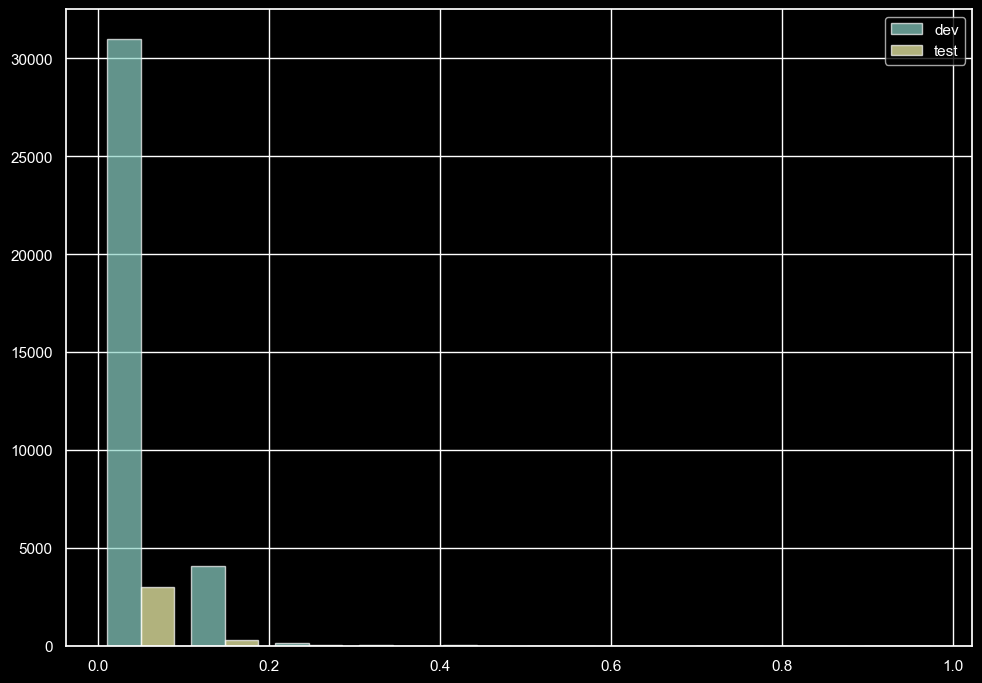

In [114]:
plt.style.use('dark_background')
plt.hist([PSI_repeated_dev.PD, PSI_repeated_test.PD], 10, alpha=0.7, label=['dev', 'test'])
plt.legend(loc='upper right')
#plt.ylim(0,8000)
plt.show()

### Тест Колмогорова-Смирнова

In [115]:
s, p=ks_2samp(PSI_repeated_dev['PD'], PSI_repeated_test['PD'])
print('statistic', s, 'p_value', format(p, ".50f"))

statistic 0.020044962589909288 p_value 0.16372587369602831230963602138217538595199584960938
